# Calibration polynomial order: 3, 5, 10 on six DR2 galaxies

- `poly3`: `new_default` rerun in `results/calibration-order/new_default` (order 3, cosmos_total, student SFH prior, free dust index, $\tau_{\rm dust}$ prior Uniform(0, 0.2)).
- The stored `results/fit-accuracy-knobs/new_default` fits used $\tau_{\rm dust}$ Uniform(0, 2); not the baseline here.
- `poly5`, `poly10`: same configuration and seeds, `CERIDWEN_CALIBRATION_ORDER` 5 and 10.
- Fits from `scripts/calibration_arms_vast.py` on one Vast RTX 5060-class GPU.
- Rule under test (meeting 2026-09-15): no calibration mode shorter than 100 angstrom.

In [1]:
import os
import shutil
import sys
from pathlib import Path

os.environ.setdefault("JAX_PLATFORMS", "cpu")
import corner
import h5py
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from numpy.polynomial.chebyshev import chebvander

PROJECT_ROOT = Path(os.environ.get("CERIDWEN_PROJECT_ROOT", Path.cwd()))
while not (PROJECT_ROOT / "scripts" / "per_galaxy_diagnostics.py").exists():
    PROJECT_ROOT = PROJECT_ROOT.parent
sys.path.insert(0, str(PROJECT_ROOT / "scripts"))
import per_galaxy_diagnostics as pgd  # noqa: E402
from build_dr2_quiescent_summary import FEH_OFFSET, formation_times  # noqa: E402
from spectral_figures import mark_absorption_features, spectral_tight_layout  # noqa: E402

TEST_ROOT = os.environ.get("CERIDWEN_ORDER_RESULTS")  # scratch tree for test runs; unset in the committed execution
RESULTS = Path(TEST_ROOT) if TEST_ROOT else PROJECT_ROOT / "results/calibration-order"
WIKI_FIGURES = Path(TEST_ROOT) / "wiki" if TEST_ROOT else PROJECT_ROOT / "wiki/analyses/calibration-order"
ARM_DIRS = {"poly3": RESULTS / "new_default",
            "poly5": RESULTS / "poly5", "poly10": RESULTS / "poly10"}
ARMS = list(ARM_DIRS)
REF_ARM = "poly3"
COLOURS = {"poly3": "k", "poly5": "tab:blue", "poly10": "tab:red"}
LABELS = {"logmass": r"$\log_{10}(M_\star/M_\odot)$", "Z": r"$[\mathrm{Fe}/\mathrm{H}]$", "afe": r"$[\alpha/\mathrm{Fe}]$",
          "tau_dust": r"$\tau_{\mathrm{dust}}$", "dust_index": r"$\delta_{\rm dust}$", "age": r"$t_{\mathrm{MW}}$ [Gyr]",
          "t50": r"$t_{50}$ [Gyr]", "f_calib": r"$f_{\rm calib}$ [%]"}
MODE_LIMIT_AA = 100.0
pd.set_option("display.width", 250); pd.set_option("display.max_columns", 80); pd.set_option("display.precision", 3)


def _text(v):
    return v.decode() if isinstance(v, bytes) else str(v)


def load_fit(folder):
    out = {"folder": folder}
    with h5py.File(folder / "ceridwen_derived_outputs.h5", "r") as d:
        out["attrs"] = dict(d.attrs)
        names = [_text(v) for v in d["summary/parameter"][:]]
        out["summary"] = pd.DataFrame({"q16": d["summary/q16"][:], "q50": d["summary/q50"][:], "q84": d["summary/q84"][:]}, index=names)
        out["diag"] = dict(d["diagnostics"].attrs)
        for grp in ("spectrum", "photometry", "sfh"):
            out[grp] = {k: d[grp][k][:] for k in d[grp]}
        out["calibration"] = {k: d["calibration"][k][:] for k in d["calibration"]}
        out["calibration"]["attrs"] = dict(d["calibration"].attrs)
    with h5py.File(folder / "ceridwen_result.h5", "r") as r:
        out["n_calls"] = int(r["samples"].attrs["n_likelihood_calls"])
        out["wall_s"] = float(r["samples"].attrs["wall_time_s"])
    out["galaxy"] = pgd.load_galaxy(folder)
    return out


def find_fits():
    fits = {}
    for arm, arm_dir in ARM_DIRS.items():
        if not arm_dir.is_dir():
            continue
        for folder in sorted(arm_dir.iterdir()):
            if (folder / "ceridwen_derived_outputs.h5").exists():
                fits[(arm, folder.name.split("-", 1)[1])] = load_fit(folder)
    return fits


fits = find_fits()
galaxies = sorted({t for a, t in fits if a == REF_ARM}, key=lambda t: fits[(REF_ARM, t)]["attrs"]["catalogue_sn"])
arms_present = [a for a in ARMS if any(arm == a for arm, _ in fits)]
print(len(fits), "fits; galaxies:", galaxies)
print({a: sorted(t for arm, t in fits if arm == a) for a in arms_present})

18 fits; galaxies: ['M12_98104', 'M5_173928', 'M4_108989', 'M12_185653', 'M1_206545', 'M5_172669']
{'poly3': ['M12_185653', 'M12_98104', 'M1_206545', 'M4_108989', 'M5_172669', 'M5_173928'], 'poly5': ['M12_185653', 'M12_98104', 'M1_206545', 'M4_108989', 'M5_172669', 'M5_173928'], 'poly10': ['M12_185653', 'M12_98104', 'M1_206545', 'M4_108989', 'M5_172669', 'M5_173928']}


## Summary table

- One row per galaxy and order; `arms.csv`.
- Raw χ² uses the observational σ; `chi2_refw` scores every order with the order-3 fit's $f_{\rm calib}$.
- Occam term: −½ ln|N|, N = DᵀD + Σ_p⁻¹, at the uncalibrated median model; its range over the 16-84 spans of $f_{\rm calib}$ and mass.

In [2]:
def half_width(row):
    return 0.5 * (row["q84"] - row["q16"])


def chi2_at_f(fit, f_pct):
    spec = fit["spectrum"]
    mask = spec["mask"].astype(bool)
    sigma = np.hypot(spec["uncertainty"], (f_pct / 100.0) * np.abs(spec["posterior_q50"]))
    return float(np.sum(((spec["observed"] - spec["posterior_q50"]) / sigma)[mask] ** 2))


def occam_range(fit):
    cal, spec, mask = fit["calibration"], fit["spectrum"], fit["spectrum"]["mask"].astype(bool)
    mu = spec["posterior_q50"] / cal["polynomial_q50"]
    basis = chebvander(cal["x"], int(cal["attrs"]["order"]))[:, 1:]
    precision = np.eye(basis.shape[1]) / float(cal["attrs"]["prior_sigma"]) ** 2
    f_lo, f_hi = fit["summary"].loc["calibration floor [%]", ["q16", "q84"]] / 100.0
    m_lo, m_hi = 10 ** (fit["summary"].loc["logmass", ["q16", "q84"]] - fit["summary"].loc["logmass", "q50"])
    values = []
    for f in (f_lo, f_hi):
        for scale in (m_lo, m_hi):
            model = scale * mu
            design = (basis * (model / np.hypot(spec["uncertainty"], f * np.abs(model)))[:, None])[mask]
            values.append(-0.5 * np.linalg.slogdet(design.T @ design + precision)[1])
    return max(values) - min(values)


def derived_row(arm, target, fit):
    spec, summary, cal = fit["spectrum"], fit["summary"], fit["calibration"]
    mask = spec["mask"].astype(bool)
    wave = spec["wavelength"][mask]
    t20, t50, t80 = formation_times(fit["sfh"]["lookback_time_gyr"], fit["sfh"]["mass_fraction_draws"])
    ref_f = fits[(REF_ARM, target)]["summary"].loc["calibration floor [%]", "q50"]
    row = dict(arm=arm, target=target, z=fit["attrs"]["redshift"], sn=fit["attrs"]["catalogue_sn"],
               seed=fit["galaxy"].seed, order=int(cal["attrs"]["order"]),
               span_obs_aa=wave.max() - wave.min(), span_rest_aa=(wave.max() - wave.min()) / (1 + fit["attrs"]["redshift"]),
               n_pix=int(mask.sum()),
               spec_chi2_raw=float(np.sum(((spec["observed"] - spec["posterior_q50"]) / spec["uncertainty"])[mask] ** 2)),
               spec_chi2_stored=float(fit["diag"]["spectrum_chi2"]), spec_chi2_refw=chi2_at_f(fit, ref_f),
               phot_chi2=float(fit["diag"]["photometry_chi2"]),
               lnZ=float(fit["diag"]["log_evidence"]), lnZ_err=float(fit["diag"]["log_evidence_err"]),
               ess=float(fit["diag"]["posterior_weight_ess"]), passed=bool(fit["diag"]["passed"]),
               calls=fit["n_calls"], wall_s=fit["wall_s"], occam_range_nats=occam_range(fit))
    for name, key in [("logmass", "logmass"), ("Z", "Z"), ("afe", "afe"), ("tau_dust", "diffuse_tau_kc"),
                      ("age", "mass-weighted age [Gyr]"), ("f_calib", "calibration floor [%]"),
                      ("scaling", "spectrum_scaling")]:
        row[f"{name}_q50"], row[f"{name}_hw"] = summary.loc[key, "q50"], half_width(summary.loc[key])
    g = fit["galaxy"]
    w = pgd.posterior_weights(g)
    q16, q50, q84 = (pgd.weighted_quantile(np.ravel(g.samples["diffuse_dust_index"]), w, q) for q in (0.16, 0.5, 0.84))
    row["dust_index_q50"], row["dust_index_hw"] = q50, 0.5 * (q84 - q16)
    q16, q50, q84 = np.percentile(t50, [16, 50, 84])
    row["t50_q50"], row["t50_hw"] = q50, 0.5 * (q84 - q16)
    p = cal["polynomial_q50"][mask]
    row["P_min"], row["P_max"], row["P_tilt"] = p.min(), p.max(), p[-1] / p[0] - 1.0
    coeff_q50 = np.median(cal["coefficient_draws"], axis=0)
    row["max_abs_a"], row["argmax_abs_a"] = np.abs(coeff_q50).max(), int(np.abs(coeff_q50).argmax()) + 1
    for i in range(cal["coefficient_draws"].shape[1]):
        q16, q50, q84 = np.percentile(cal["coefficient_draws"][:, i], [16, 50, 84])
        row[f"a{i + 1}_q50"], row[f"a{i + 1}_hw"] = q50, 0.5 * (q84 - q16)
    return row


table = pd.DataFrame([derived_row(a, t, f) for (a, t), f in fits.items()]).set_index(["target", "arm"]).sort_index()
show = ["z", "sn", "order", "span_obs_aa", "n_pix", "spec_chi2_raw", "spec_chi2_refw", "spec_chi2_stored", "phot_chi2",
        "f_calib_q50", "logmass_q50", "t50_q50", "t50_hw", "tau_dust_q50", "tau_dust_hw", "dust_index_q50", "age_q50", "age_hw",
        "P_min", "P_max", "P_tilt", "max_abs_a", "argmax_abs_a", "occam_range_nats", "lnZ", "lnZ_err", "wall_s"]
display(table[show])

z     sn  order  span_obs_aa  n_pix  spec_chi2_raw  spec_chi2_refw  spec_chi2_stored  phot_chi2  f_calib_q50  logmass_q50  t50_q50  t50_hw  tau_dust_q50  tau_dust_hw  dust_index_q50  age_q50  age_hw  P_min  P_max  P_tilt  \
target     arm                                                                                                                                                                                                                                        
M12_185653 poly10  0.678   21.5     10     2468.466   3577       9507.115        3869.849          3988.422      9.767        6.115       11.064    4.673   0.504         0.187        0.016           0.062    4.597   0.345  0.920  1.049   0.104   
           poly3   0.678   21.5      3     2468.466   3577       9842.613        3982.470          3989.772     10.893        6.295       11.074    4.789   0.510         0.187        0.017          -0.097    4.703   0.379  0.937  1.034   0.087   
           poly5   0.678   21.5      5     2468.466   3577       9648.282        3916.861          3968.370      9.569        6.221       11.045    4.338   0.395         0.180        0.021           0.046    4.344   0.307  0.882  1.056   0.156   
M12_98104  poly10  0.981    6.6     10     2469.066   3804       8540.897        5842.868          5842.266     14.505        9.985       11.158    4.065   0.547         0.192        0.009          -0.816    3.907   0.464  0.867  1.095   0.177   
           poly3   0.981    6.6      3     2469.066   3804       8671.049        5922.800          5922.820     25.161        9.981       11.142    4.046   0.525         0.195        0.005          -0.937    3.910   0.462  0.944  1.093   0.138   
           poly5   0.981    6.6      5     2469.066   3804       8624.036        5898.480          5898.059     19.157        9.983       11.092    3.348   0.310         0.195        0.005          -0.944    3.279   0.263  0.940  1.078   0.098   
M1_206545  poly10  0.728   31.4     10     2450.462   3422       7609.673        3694.957          4333.334     45.607        3.349       11.614    6.068   0.006         0.197        0.003          -0.978    6.066   0.011  0.810  1.150   0.165   
           poly3   0.728   31.4      3     2450.462   3422       8982.719        4224.027          4217.368     63.817        4.165       11.552    5.102   0.056         0.198        0.002          -0.992    5.085   0.031  0.787  1.113   0.268   
           poly5   0.728   31.4      5     2450.462   3422       8921.898        4215.401          4237.489     68.324        4.143       11.550    5.106   0.069         0.199        0.002          -0.992    5.085   0.039  0.809  1.112   0.242   
M4_108989  poly10  0.828   21.3     10     2415.652   3735       7274.876        3679.093          4286.341     20.673        3.613       11.809    5.153   0.158         0.197        0.004          -0.976    4.985   0.109  0.870  1.084  -0.020   
           poly3   0.828   21.3      3     2415.652   3735       8643.322        4255.968          4257.058     16.566        4.411       11.792    4.845   0.208         0.193        0.008          -0.888    4.691   0.143  0.941  1.048  -0.049   
           poly5   0.828   21.3      5     2415.652   3735       7417.589        3753.819          4316.950     17.891        3.667       11.813    5.153   0.168         0.197        0.004          -0.981    4.976   0.121  0.892  1.118  -0.065   
M5_172669  poly10  0.604  105.0     10     2473.268   3602      23125.806        3190.731          4008.556     11.034        2.396       11.337    2.293   0.205         0.197        0.003          -0.975    2.719   0.352  0.859  1.089  -0.211   
           poly3   0.604  105.0      3     2473.268   3602      30085.728        3993.517          3985.610     12.880        2.772       11.305    1.997   0.105         0.199        0.001          -0.993    2.212   0.164  0.925  1.084  -0.147   
           poly5   0.604  105.0      5     2473.268   3602      28761.9

## Shortest calibration mode against the 100 angstrom rule

- Mode length from the fitted span and the order; verdict against `MODE_LIMIT_AA`.
- Observed and rest-frame spans both listed; the rule's frame is not fixed in the meeting note.

In [3]:
def shortest_mode_length(span_aa, order):
    """Shortest wavelength scale, in angstrom, that a Chebyshev P(x) of this order can bend on.

    `span_aa` is the fitted wavelength span mapped onto x in [-1, 1]; `order` is
    the highest T_n kept. Return one float in angstrom.
    """
    return span_aa / order


modes = table.reset_index()[["target", "arm", "order", "span_obs_aa", "span_rest_aa"]].copy()
modes["mode_obs_aa"] = [shortest_mode_length(s, n) for s, n in zip(modes["span_obs_aa"], modes["order"])]
modes["mode_rest_aa"] = [shortest_mode_length(s, n) for s, n in zip(modes["span_rest_aa"], modes["order"])]
modes["passes_rule_obs"] = modes["mode_obs_aa"] >= MODE_LIMIT_AA
modes["passes_rule_rest"] = modes["mode_rest_aa"] >= MODE_LIMIT_AA
modes["order_at_limit_obs"] = [int(np.floor(n * m / MODE_LIMIT_AA)) for n, m in zip(modes["order"], modes["mode_obs_aa"])]
modes = modes.set_index(["target", "arm"]).sort_index()
table = table.join(modes[["mode_obs_aa", "mode_rest_aa", "passes_rule_obs", "passes_rule_rest", "order_at_limit_obs"]])
table.to_csv(RESULTS / "arms.csv")
display(modes)

order  span_obs_aa  span_rest_aa  mode_obs_aa  mode_rest_aa  passes_rule_obs  passes_rule_rest  order_at_limit_obs
target     arm                                                                                                                       
M12_185653 poly10     10     2468.466      1471.400      246.847       147.140             True              True                  24
           poly3       3     2468.466      1471.400      822.822       490.467             True              True                  24
           poly5       5     2468.466      1471.400      493.693       294.280             True              True                  24
M12_98104  poly10     10     2469.066      1246.111      246.907       124.611             True              True                  24
           poly3       3     2469.066      1246.111      823.022       415.370             True              True                  24
           poly5       5     2469.066      1246.111      493.813       249.222             True              True                  24
M1_206545  poly10     10     2450.462      1417.845      245.046       141.785             True              True                  24
           poly3       3     2450.462      1417.845      816.821       472.615             True              True                  24
           poly5       5     2450.462      1417.845      490.092       283.569             True              True                  24
M4_108989  poly10     10     2415.652      1321.617      241.565       132.162             True              True                  24
           poly3       3     2415.652      1321.617      805.217       440.539             True              True                  24
           poly5       5     2415.652      1321.617      483.130       264.323             True              True                  24
M5_172669  poly10     10     2473.268      1542.226      247.327       154.223             True              True                  24
           poly3       3     2473.268      1542.226      824.423       514.075             True              True                  24
           poly5       5     2473.268      1542.226      494.654       308.445             True              True                  24
M5_173928  poly10     10     2456.463      1253.937      245.646       125.394             True              True                  24
           poly3       3     2456.463      1253.937      818.821       417.979             True              True                  24
           poly5       5     2456.463      1253.937      491.293       250.787             True              True                  24

## Change against order 3, per galaxy

- Δ = this order minus `poly3`, same seed and sampler settings.
- `dchi2_refw`: both fits scored with the order-3 $f_{\rm calib}$, so the weights are equal.
- `before-after.csv`.

In [4]:
rows = []
for target in galaxies:
    base = table.loc[(target, REF_ARM)]
    for arm in [a for a in arms_present if a != REF_ARM]:
        if (target, arm) not in table.index:
            continue
        cur = table.loc[(target, arm)]
        rows.append(dict(
            target=target, arm=arm, order=cur["order"],
            dchi2_raw=cur["spec_chi2_raw"] - base["spec_chi2_raw"],
            dchi2_refw=cur["spec_chi2_refw"] - base["spec_chi2_refw"],
            dchi2_phot=cur["phot_chi2"] - base["phot_chi2"],
            dlnZ=cur["lnZ"] - base["lnZ"],
            df_calib=cur["f_calib_q50"] - base["f_calib_q50"],
            dlogmass=cur["logmass_q50"] - base["logmass_q50"],
            dt50=cur["t50_q50"] - base["t50_q50"], dt50_sigma=(cur["t50_q50"] - base["t50_q50"]) / base["t50_hw"],
            dtau=cur["tau_dust_q50"] - base["tau_dust_q50"], dtau_sigma=(cur["tau_dust_q50"] - base["tau_dust_q50"]) / base["tau_dust_hw"],
            ddust_index=cur["dust_index_q50"] - base["dust_index_q50"],
            dage=cur["age_q50"] - base["age_q50"], dage_sigma=(cur["age_q50"] - base["age_q50"]) / base["age_hw"],
            dP_tilt=cur["P_tilt"] - base["P_tilt"], dwall_s=cur["wall_s"] - base["wall_s"],
        ))
before_after = pd.DataFrame(rows).set_index(["target", "arm"]).sort_index() if rows else pd.DataFrame()
before_after.to_csv(RESULTS / "before-after.csv")
display(before_after)

order  dchi2_raw  dchi2_refw  dchi2_phot     dlnZ  df_calib  dlogmass   dt50  dt50_sigma       dtau  dtau_sigma  ddust_index       dage  dage_sigma  dP_tilt  dwall_s
target     arm                                                                                                                                                                          
M12_185653 poly10     10   -335.498    -112.621      -1.126   29.052    -0.180    -0.010 -0.116      -0.228  1.366e-04       0.008    1.588e-01 -1.052e-01      -0.277    0.017  325.506
           poly5       5   -194.332     -65.609      -1.324   23.253    -0.074    -0.029 -0.452      -0.886 -6.603e-03      -0.391    1.431e-01 -3.587e-01      -0.946    0.069   40.903
M12_98104  poly10     10   -130.151     -79.932     -10.656   20.448     0.003     0.016  0.019       0.037 -2.765e-03      -0.540    1.214e-01 -3.135e-03      -0.007    0.040  320.098
           poly5       5    -47.013     -24.320      -6.004    4.357     0.002    -0.050 -0.698      -1.330  1.835e-04       0.036   -6.400e-03 -6.314e-01      -1.368   -0.040   65.425
M1_206545  poly10     10  -1373.047    -529.070     -18.210  304.821    -0.816     0.062  0.966      17.253 -9.717e-04      -0.573    1.399e-02  9.816e-01      32.092   -0.104  411.163
           poly5       5    -60.821      -8.625       4.507   -1.868    -0.022    -0.002  0.003       0.059  1.112e-04       0.066   -4.819e-05  7.106e-04       0.023   -0.026   72.007
M4_108989  poly10     10  -1368.446    -576.875       4.107  284.353    -0.798     0.017  0.308       1.480  3.965e-03       0.494   -8.888e-02  2.940e-01       2.060    0.029  434.710
           poly5       5  -1225.733    -502.149       1.325  263.058    -0.744     0.020  0.308       1.476  4.392e-03       0.547   -9.367e-02  2.842e-01       1.991   -0.016   61.111
M5_172669  poly10     10  -6959.923    -802.786      -1.846  427.182    -0.376     0.032  0.296       2.812 -1.728e-03      -1.431    1.775e-02  5.067e-01       3.082   -0.064  479.308
           poly5       5  -1323.820    -186.801       1.140   82.036    -0.057     0.002  0.121       1.148  9.715e-05       0.080    1.115e-03  8.397e-02       0.511   -0.015   55.578
M5_173928  poly10     10  -4921.308   -1028.219      36.771  554.962    -2.170     0.028  0.486       2.044 -5.515e-05      -0.042    1.581e-03  7.423e-01       4.783    0.224  468.111
           poly5       5  -1050.389    -382.432      10.042  224.257    -0.493     0.026  0.460       1.932  4.069e-05       0.031   -9.240e-04  6.412e-01       4.131    0.156   75.545

## The calibration vector by order

- $P(\lambda)$: median and 16-84 band over fitted pixels; dotted across masked pixels.
- Right: $P(\lambda)$ minus the order-3 median, the extra structure the higher orders add.

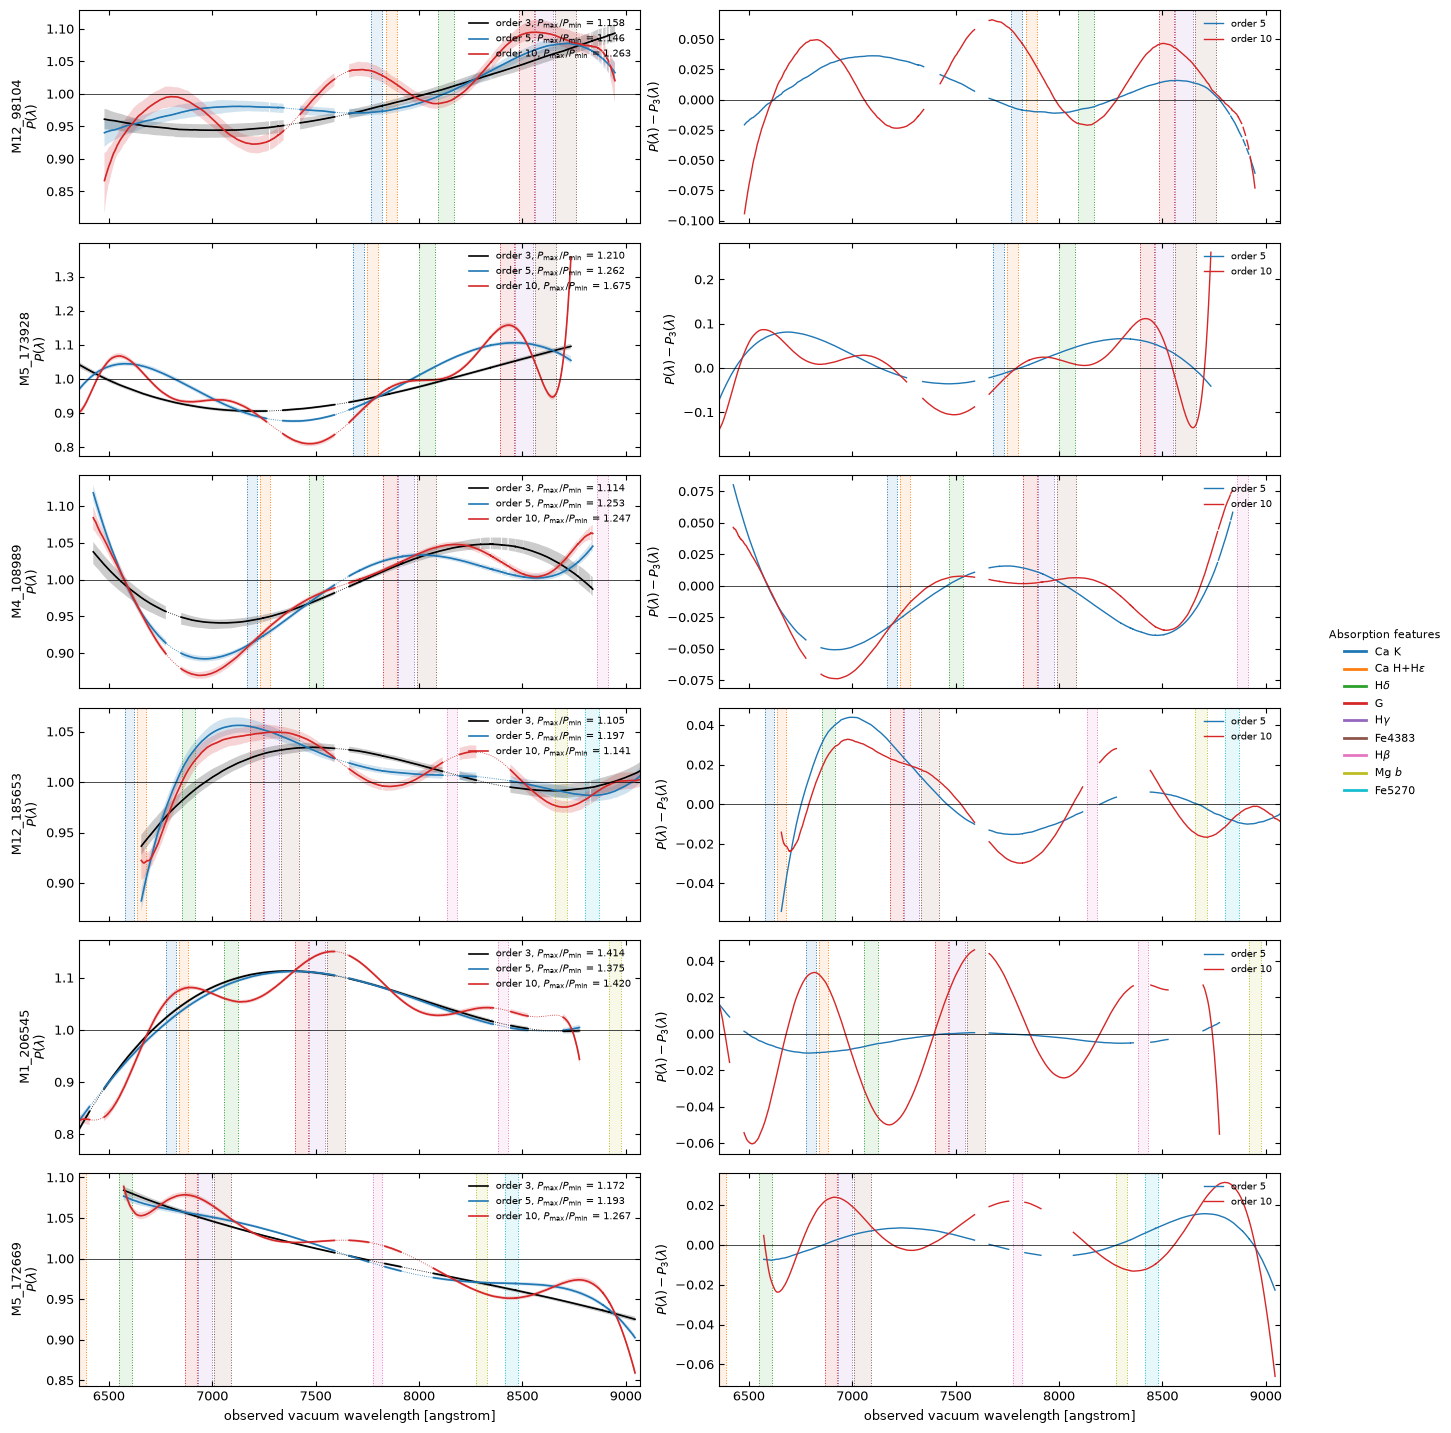

In [5]:
fig, axes = plt.subplots(len(galaxies), 2, figsize=(13, 2.4 * len(galaxies)), squeeze=False, sharex=True)
for row_axes, target in zip(axes, galaxies):
    ref = fits[(REF_ARM, target)]
    ref_p = ref["calibration"]["polynomial_q50"]
    for arm in arms_present:
        if (arm, target) not in fits:
            continue
        fit = fits[(arm, target)]
        cal, wave, mask = fit["calibration"], fit["spectrum"]["wavelength"], fit["spectrum"]["mask"].astype(bool)
        inside = (wave >= wave[mask].min()) & (wave <= wave[mask].max())
        label = f"order {cal['attrs']['order']}, $P_{{\\max}}/P_{{\\min}}$ = {cal['polynomial_q50'][mask].max() / cal['polynomial_q50'][mask].min():.3f}"
        row_axes[0].fill_between(wave, np.where(mask, cal["polynomial_q16"], np.nan), np.where(mask, cal["polynomial_q84"], np.nan),
                                 color=COLOURS[arm], alpha=0.2, lw=0)
        row_axes[0].plot(wave, np.where(inside, cal["polynomial_q50"], np.nan), color=COLOURS[arm], lw=0.6, ls=":")
        row_axes[0].plot(wave, np.where(mask, cal["polynomial_q50"], np.nan), color=COLOURS[arm], lw=1.2, label=label)
        if arm != REF_ARM:
            row_axes[1].plot(wave, np.where(mask, cal["polynomial_q50"] - ref_p, np.nan), color=COLOURS[arm], lw=1.0, label=f"order {cal['attrs']['order']}")
    row_axes[0].axhline(1.0, color="k", lw=0.5); row_axes[1].axhline(0.0, color="k", lw=0.5)
    row_axes[0].set_ylabel(f"{target}\n$P(\\lambda)$"); row_axes[1].set_ylabel(r"$P(\lambda) - P_{3}(\lambda)$")
    for ax in row_axes:
        ax.legend(frameon=False, fontsize=7, loc="upper right")
    bottom = target == galaxies[-1]
    for ax in row_axes:
        mark_absorption_features(ax, ref["attrs"]["redshift"], show_labels=bottom,
                                 xlabel="observed vacuum wavelength [angstrom]" if bottom else None)
spectral_tight_layout(fig)
fig.savefig(RESULTS / "polynomial-vectors.png", dpi=130); plt.show()

## Coefficient spectrum

- $|a_n|$ posterior median and 16-84 range against $n$, per galaxy and order.
- Dashed line: the prior width $\sigma_p$ = 0.1.

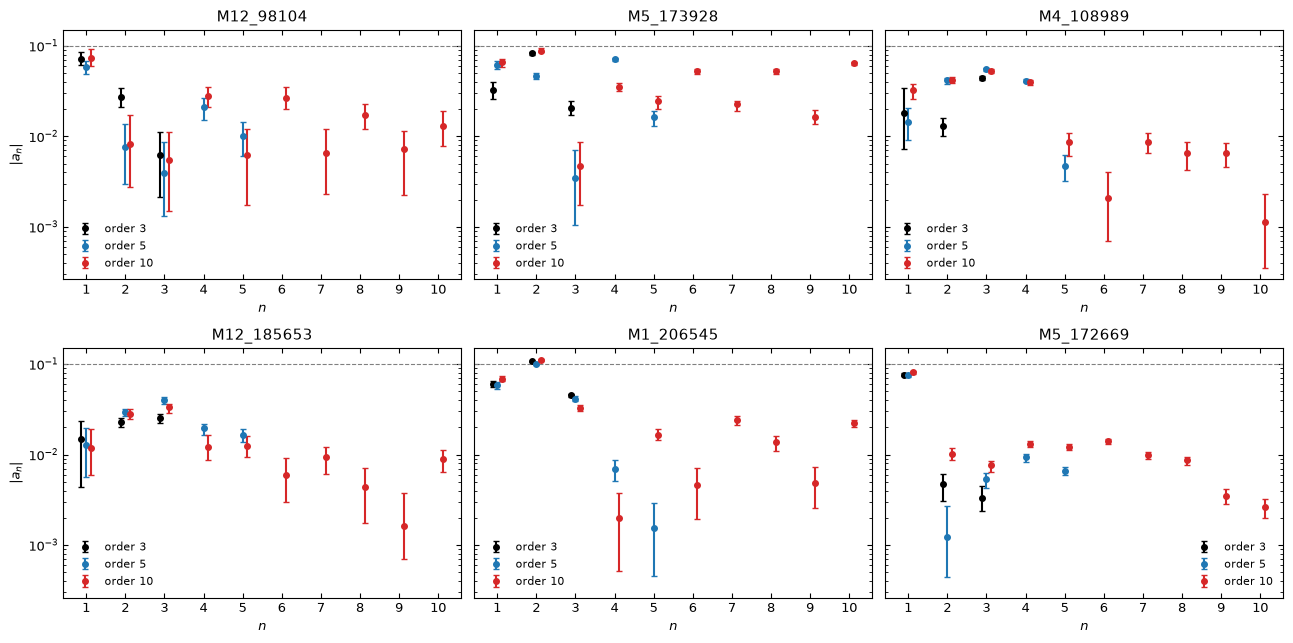

In [6]:
fig, axes = plt.subplots(2, 3, figsize=(13, 6.5), squeeze=False, sharey=True)
for ax, target in zip(axes.ravel(), galaxies):
    for j, arm in enumerate(arms_present):
        if (arm, target) not in fits:
            continue
        draws = fits[(arm, target)]["calibration"]["coefficient_draws"]
        n = np.arange(1, draws.shape[1] + 1) + 0.12 * (j - 1)
        q16, q50, q84 = np.percentile(np.abs(draws), [16, 50, 84], axis=0)
        ax.errorbar(n, q50, yerr=[q50 - q16, q84 - q50], fmt="o", ms=4, color=COLOURS[arm], capsize=2, label=f"order {draws.shape[1]}")
    ax.axhline(fits[(REF_ARM, target)]["calibration"]["attrs"]["prior_sigma"], color="0.5", ls="--", lw=0.8)
    ax.set(yscale="log", title=target, xlabel="$n$")
    ax.set_xticks(range(1, 11))
    ax.legend(frameon=False, fontsize=8)
for ax in axes[:, 0]:
    ax.set_ylabel(r"$|a_n|$")
fig.tight_layout(); fig.savefig(RESULTS / "coefficients.png", dpi=130); plt.show()

## Spectral residuals by order

- Top: pull with the order-3 $f_{\rm calib}$ for every order, fitted pixels only.
- Bottom: cumulative raw χ² along the spectrum. Grey: masked pixels.

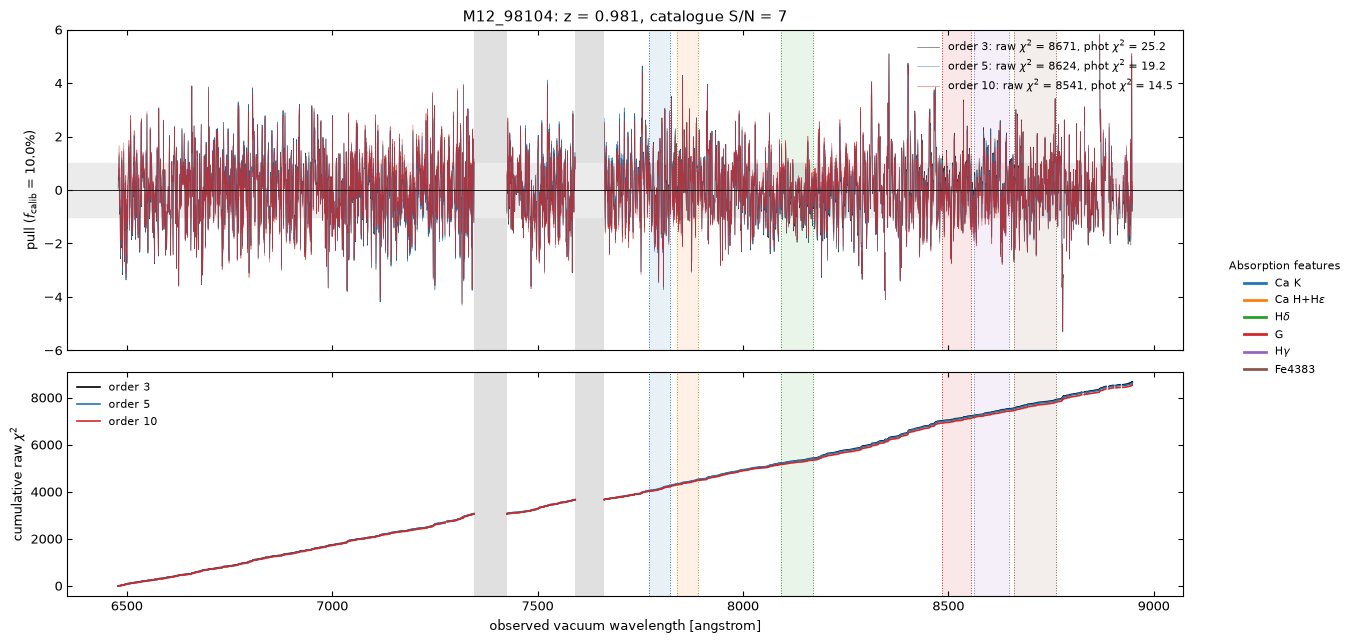

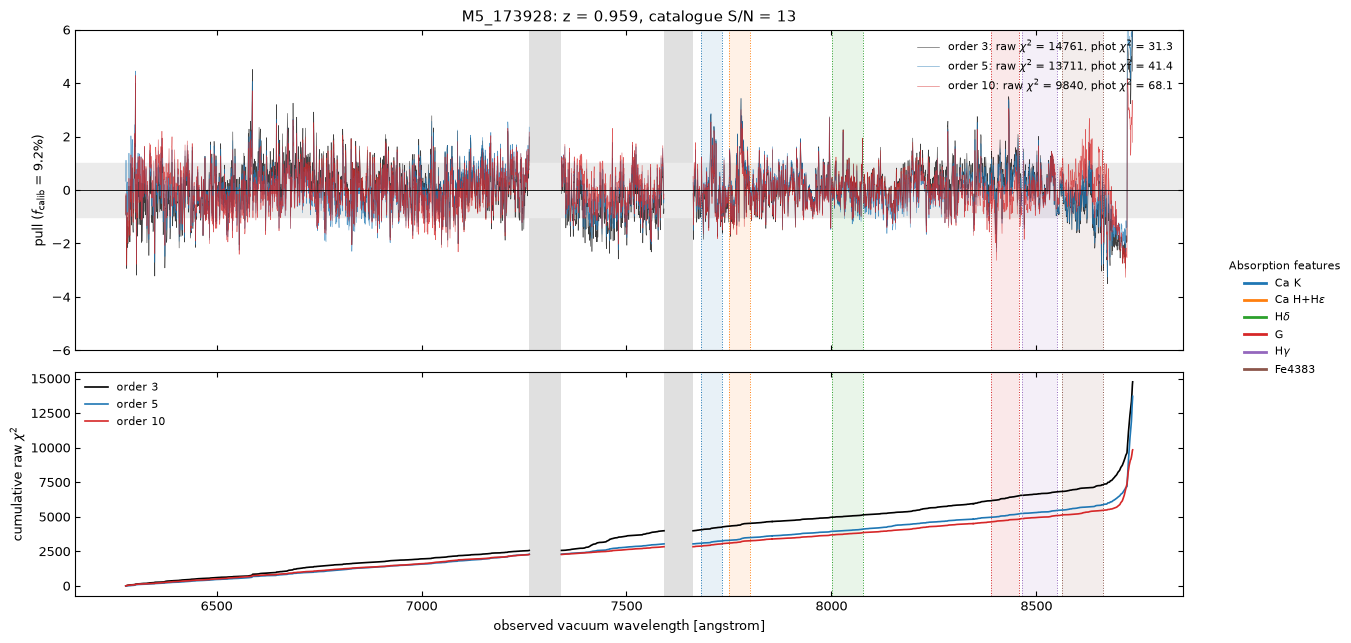

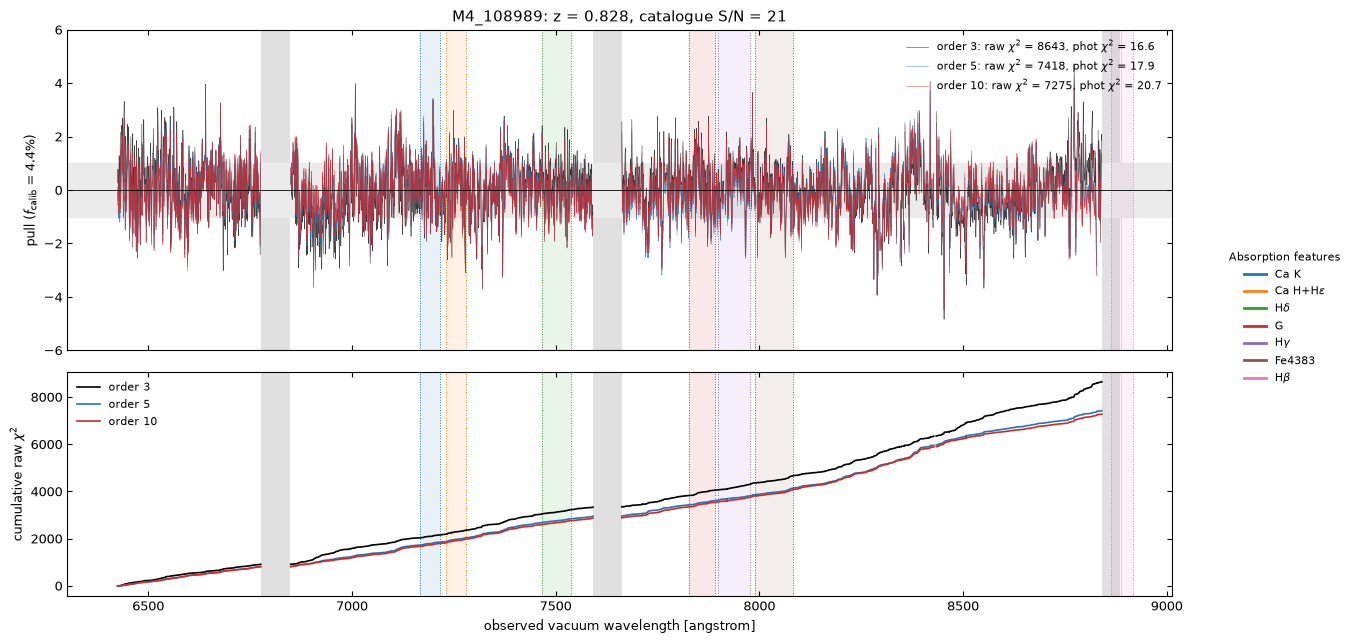

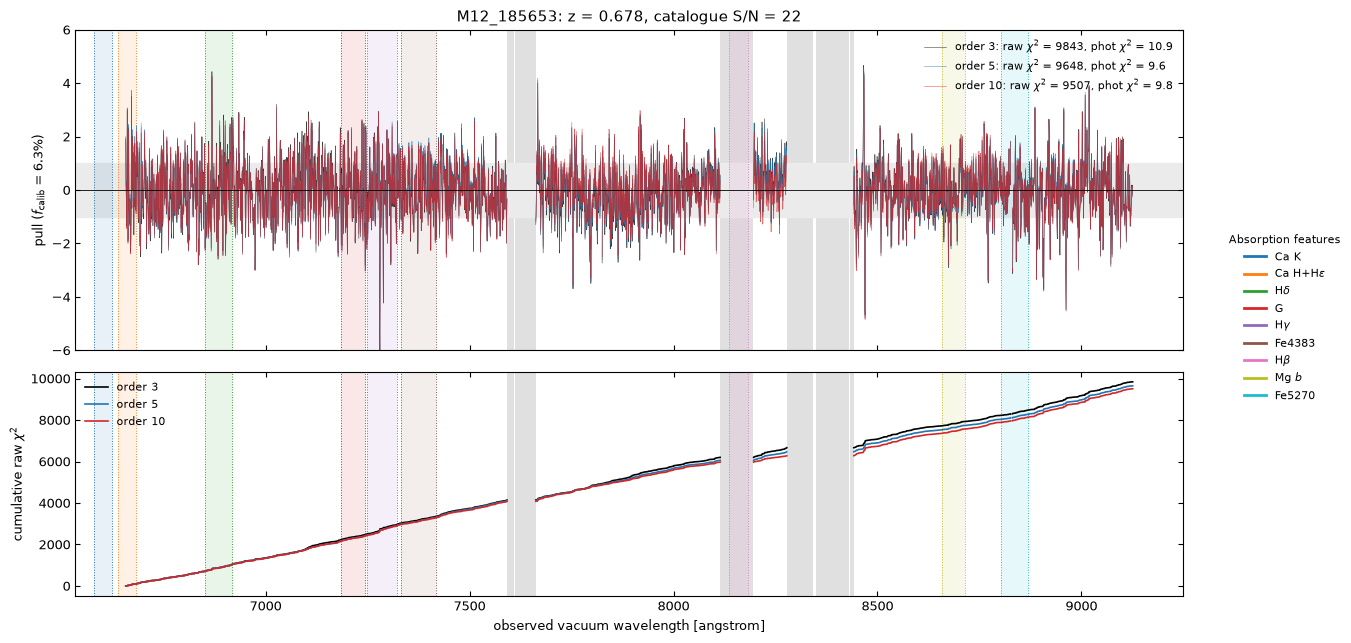

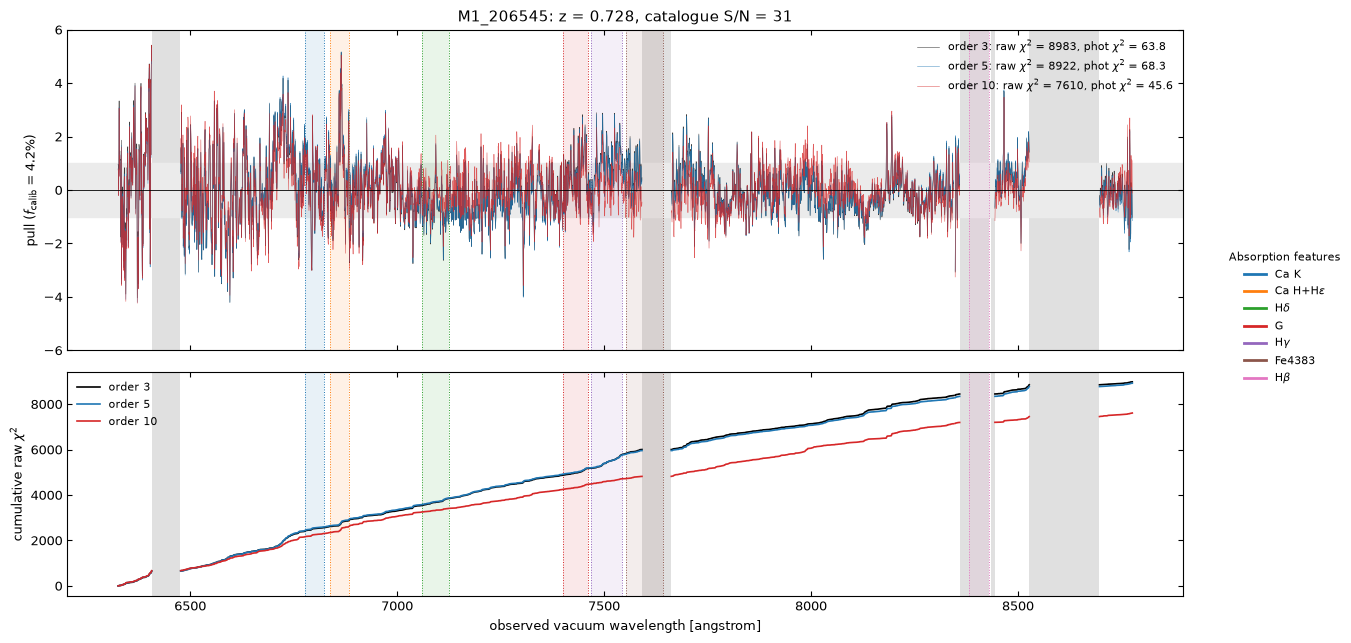

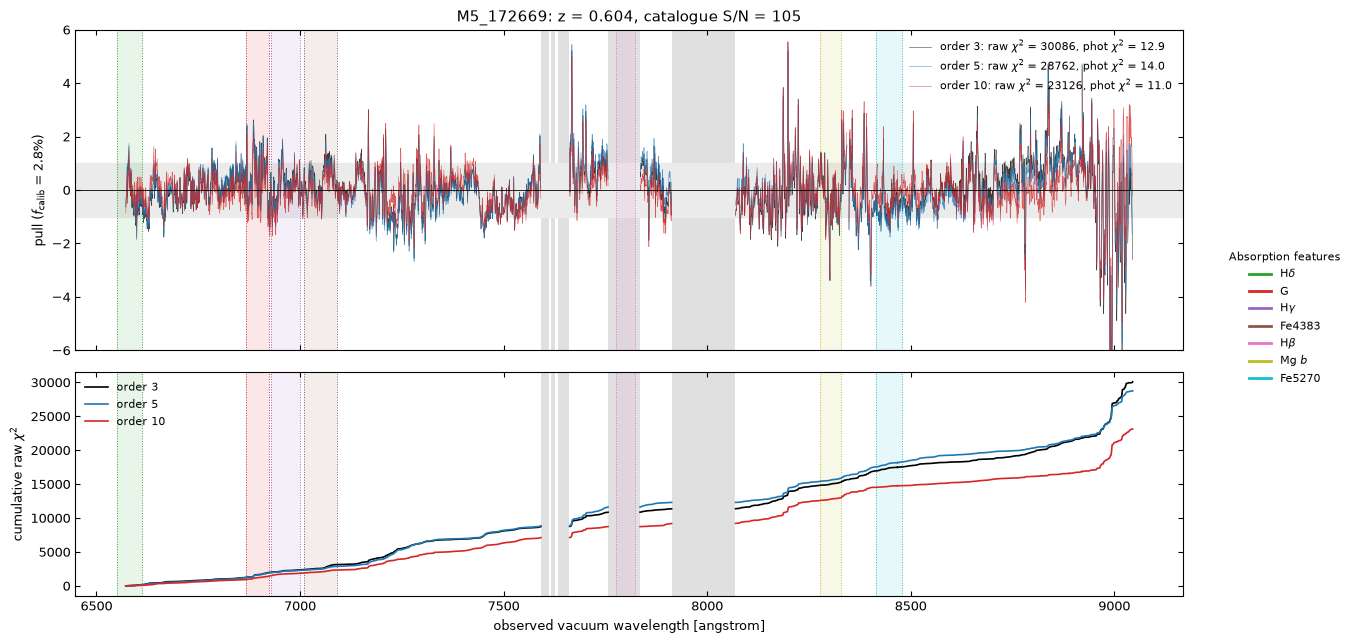

In [7]:
def _runs(wave, flag):
    edges = np.flatnonzero(np.diff(np.concatenate([[0], flag.astype(int), [0]])))
    return [(wave[s], wave[min(e, wave.size) - 1]) for s, e in zip(edges[::2], edges[1::2])]


def pull_at_f(fit, f_pct):
    s = fit["spectrum"]
    sigma = np.hypot(s["uncertainty"], (f_pct / 100.0) * np.abs(s["posterior_q50"]))
    return (s["observed"] - s["posterior_q50"]) / sigma


def residual_figure(target):
    ref = fits[(REF_ARM, target)]
    s = ref["spectrum"]; wave = s["wavelength"]; rmask = s["mask"].astype(bool)
    excluded = (s["uncertainty"] < 1.0) & ~rmask
    ref_f = ref["summary"].loc["calibration floor [%]", "q50"]
    fig, axes = plt.subplots(2, 1, figsize=(12, 6.5), sharex=True, gridspec_kw={"height_ratios": [2, 1.4]})
    for ax in axes:
        for lo, hi in _runs(wave, excluded):
            ax.axvspan(lo, hi, color="0.88", lw=0, zorder=0)
    for arm in arms_present:
        if (arm, target) not in fits:
            continue
        fit = fits[(arm, target)]; mask = fit["spectrum"]["mask"].astype(bool)
        row = table.loc[(target, arm)]
        pull = pull_at_f(fit, ref_f)
        raw = ((fit["spectrum"]["observed"] - fit["spectrum"]["posterior_q50"]) / fit["spectrum"]["uncertainty"]) ** 2
        axes[0].plot(wave, np.where(mask, pull, np.nan), lw=0.4, color=COLOURS[arm], alpha=0.75,
                     label=f"order {row['order']}: raw $\\chi^2$ = {row['spec_chi2_raw']:.0f}, phot $\\chi^2$ = {row['phot_chi2']:.1f}")
        axes[1].plot(wave, np.where(mask, np.cumsum(np.where(mask, raw, 0.0)), np.nan), lw=1.2, color=COLOURS[arm], label=f"order {row['order']}")
    axes[0].axhspan(-1, 1, color="0.92", zorder=0); axes[0].axhline(0, color="k", lw=0.6); axes[0].set_ylim(-6, 6)
    axes[0].set_ylabel(f"pull ($f_{{\\rm calib}}$ = {ref_f:.1f}%)")
    axes[0].set_title(f"{target}: z = {ref['attrs']['redshift']:.3f}, catalogue S/N = {ref['attrs']['catalogue_sn']:.0f}")
    axes[0].legend(frameon=False, fontsize=8, loc="upper right")
    axes[1].set_ylabel(r"cumulative raw $\chi^2$")
    axes[1].legend(frameon=False, fontsize=8, loc="upper left")
    mark_absorption_features(axes[0], ref["attrs"]["redshift"], show_labels=False)
    mark_absorption_features(axes[1], ref["attrs"]["redshift"], xlabel="observed vacuum wavelength [angstrom]")
    spectral_tight_layout(fig)
    fig.savefig(RESULTS / f"chi2-{target}.png", dpi=130); plt.show()


for target in galaxies:
    residual_figure(target)

## Fit per galaxy

- Spectrum medians for every order; photometry with χ² per order.

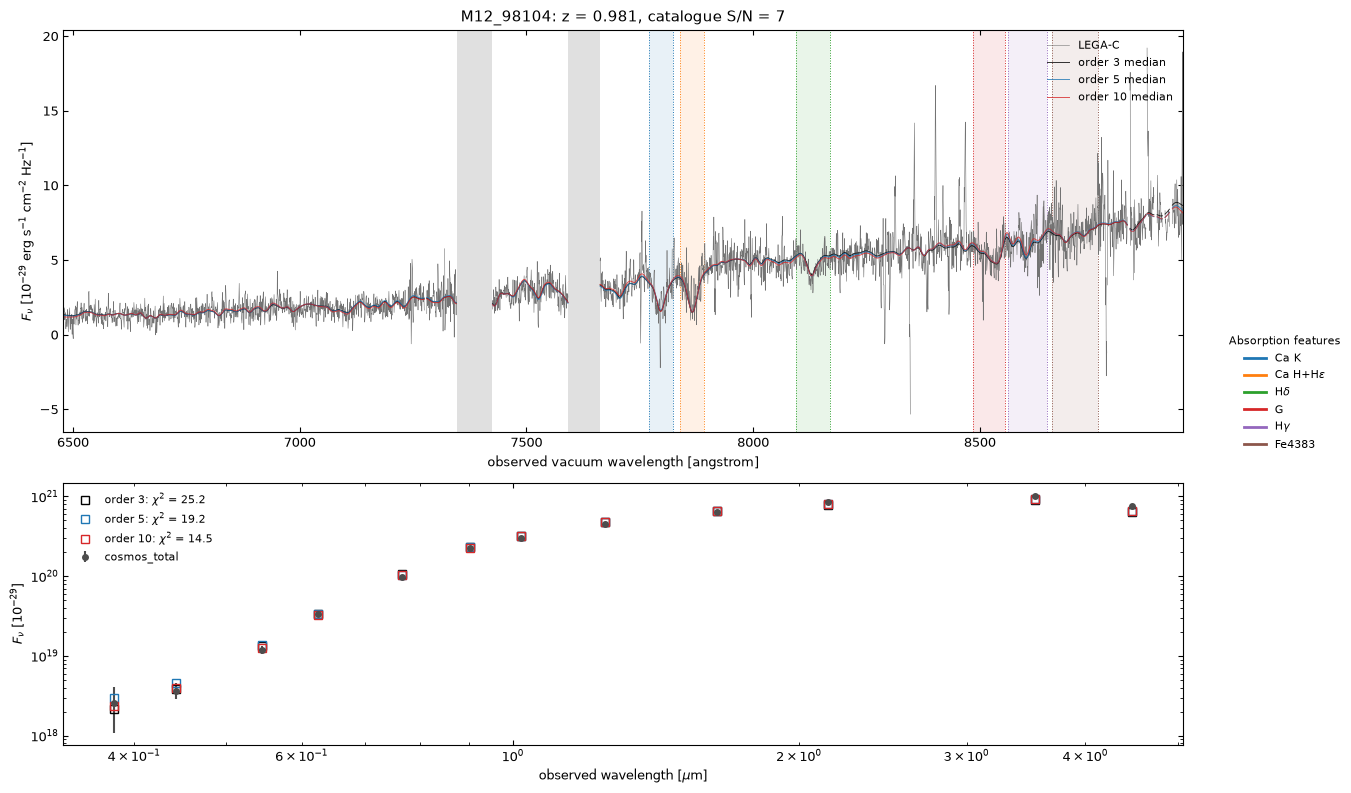

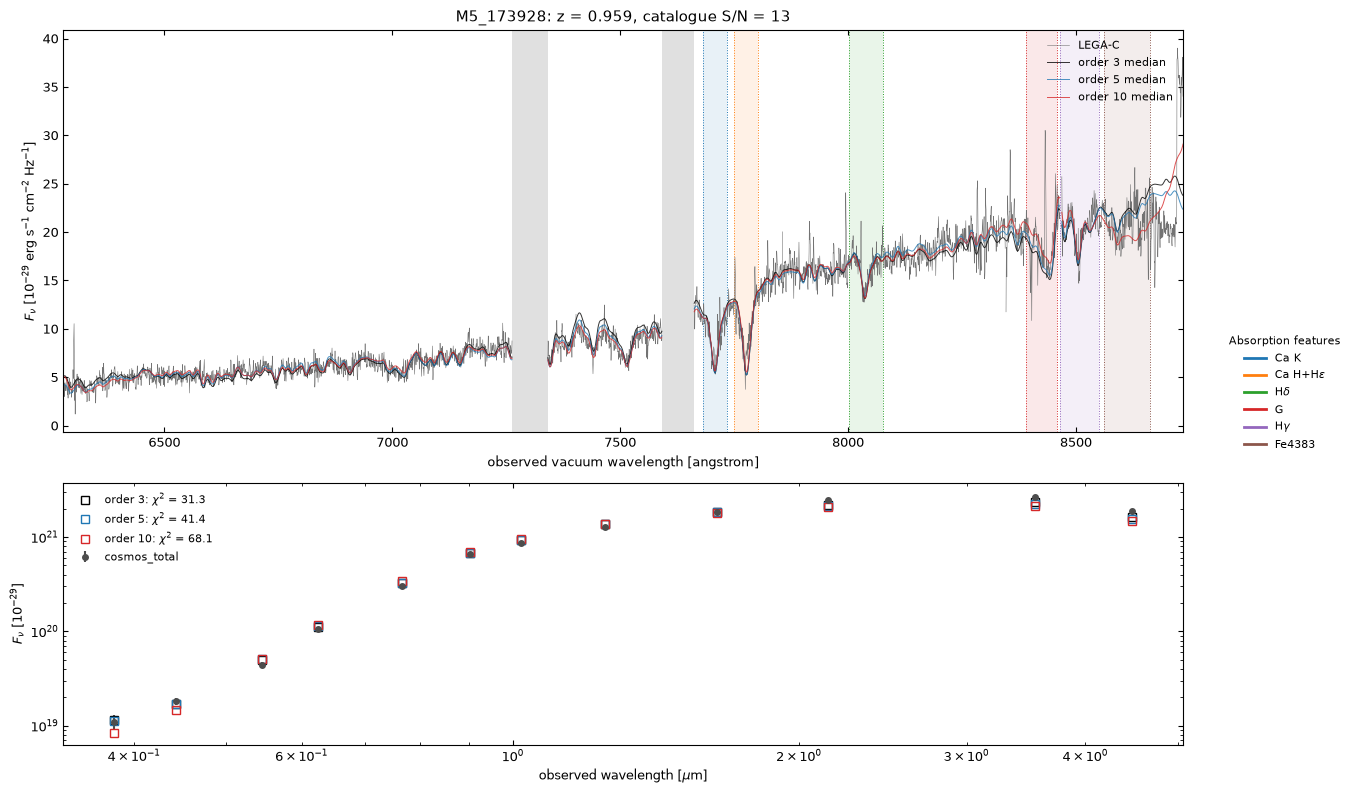

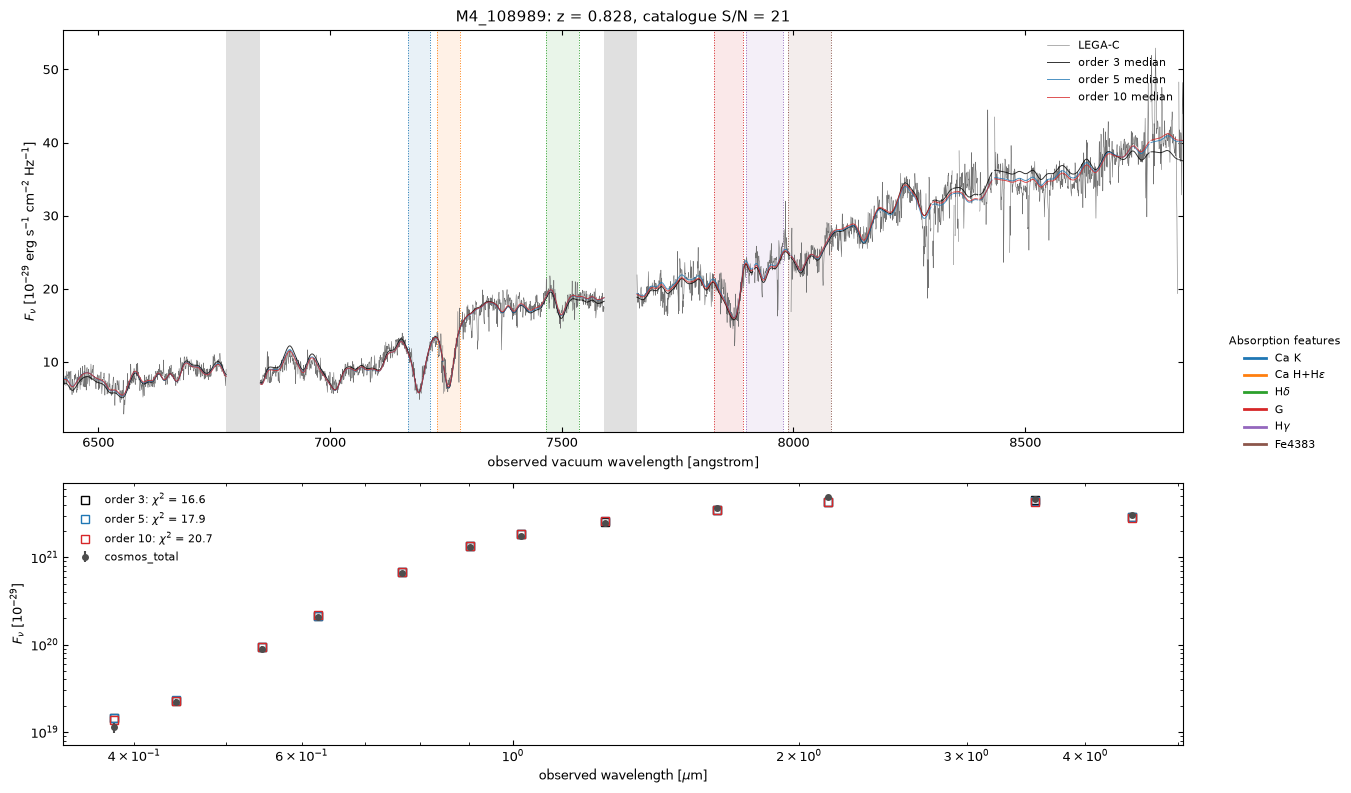

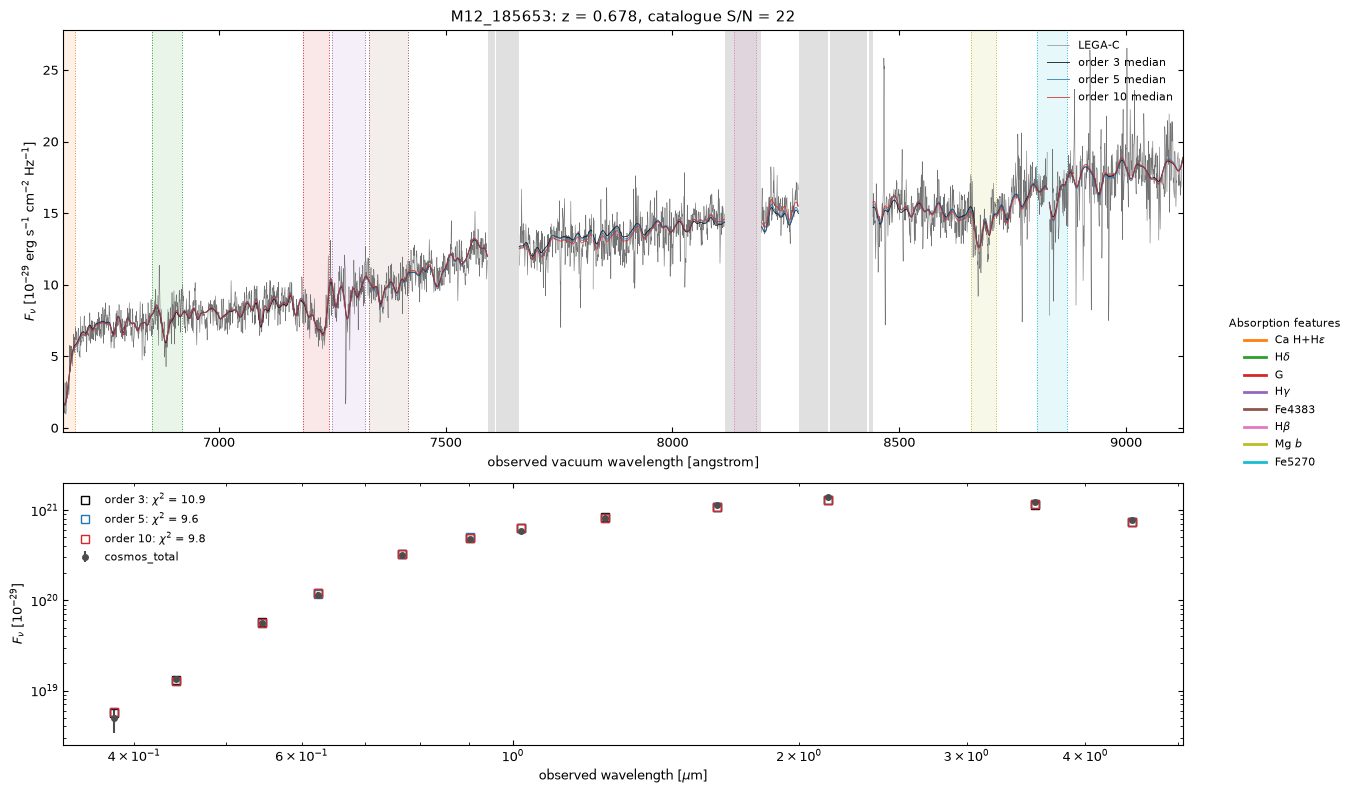

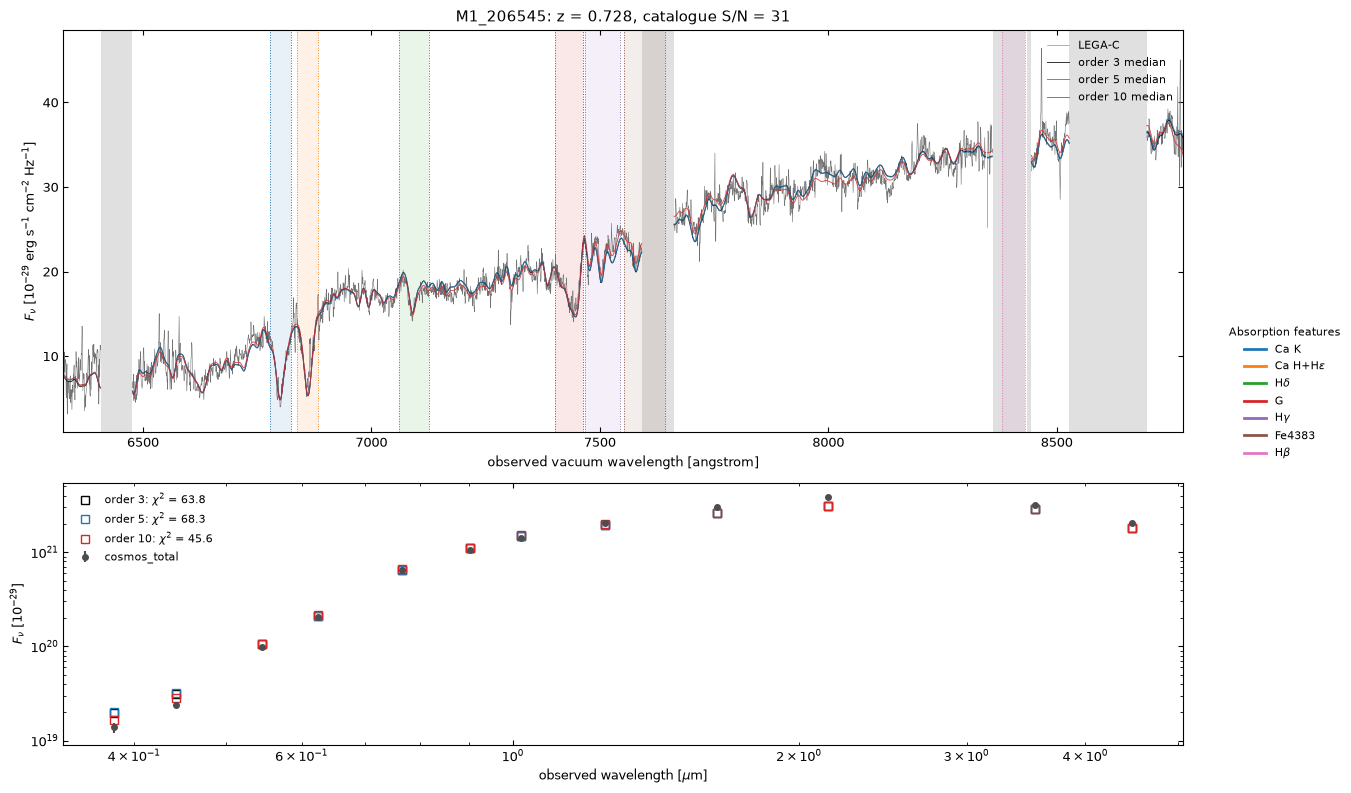

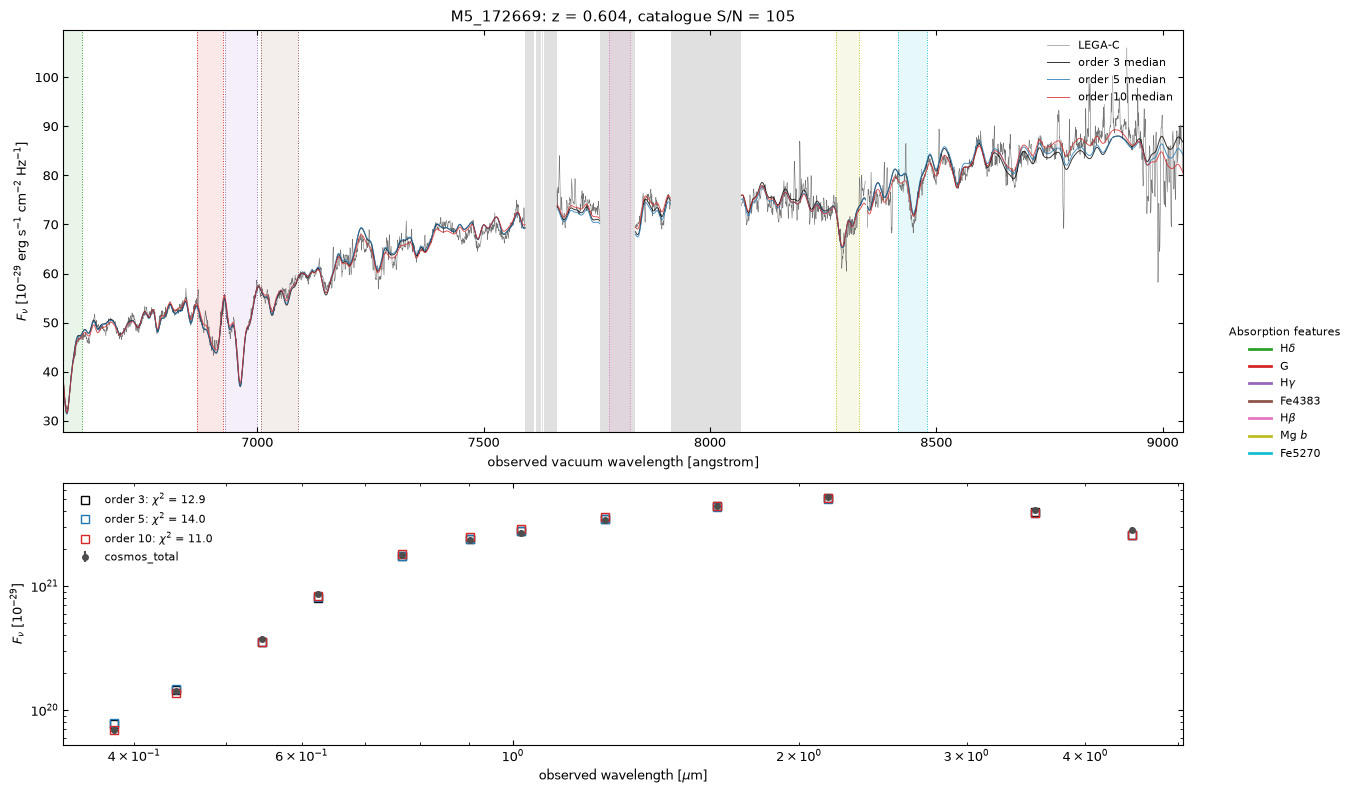

In [8]:
def fit_figure(target):
    ref = fits[(REF_ARM, target)]
    s = ref["spectrum"]; wave = s["wavelength"]; rmask = s["mask"].astype(bool)
    excluded = (s["uncertainty"] < 1.0) & ~rmask
    fig, axes = plt.subplots(2, 1, figsize=(12, 8), gridspec_kw={"height_ratios": [2, 1.3]})
    for lo, hi in _runs(wave, excluded):
        axes[0].axvspan(lo, hi, color="0.88", lw=0, zorder=0)
    scale = 1e29
    axes[0].plot(wave, np.where(rmask, s["observed"] * scale, np.nan), color="0.45", lw=0.4, label="LEGA-C")
    p = ref["photometry"]; pm = p["mask"].astype(bool); lam = p["wavelength"] / 1e4
    axes[1].errorbar(lam[pm], p["observed"][pm] * scale, yerr=p["uncertainty"][pm] * scale, fmt="o", color="0.3", ms=4, label="cosmos_total")
    for arm in arms_present:
        if (arm, target) not in fits:
            continue
        fit = fits[(arm, target)]; order = fit["calibration"]["attrs"]["order"]
        axes[0].plot(wave, np.where(rmask, fit["spectrum"]["posterior_q50"] * scale, np.nan), color=COLOURS[arm], lw=0.7, alpha=0.8, label=f"order {order} median")
        q = fit["photometry"]
        axes[1].plot(lam[pm], q["posterior_q50"][pm] * scale, "s", mfc="none", color=COLOURS[arm], ms=6, label=rf"order {order}: $\chi^2$ = {np.sum(q['pull'][pm] ** 2):.1f}")
    axes[0].set_xlim(wave[rmask].min(), wave[rmask].max())
    axes[0].set_ylabel(r"$F_\nu$ [$10^{-29}$ erg s$^{-1}$ cm$^{-2}$ Hz$^{-1}$]")
    axes[0].set_title(f"{target}: z = {ref['attrs']['redshift']:.3f}, catalogue S/N = {ref['attrs']['catalogue_sn']:.0f}")
    axes[0].legend(frameon=False, fontsize=8, loc="upper right")
    axes[1].set(xscale="log", yscale="log", xlabel=r"observed wavelength [$\mu$m]", ylabel=r"$F_\nu$ [$10^{-29}$]")
    axes[1].legend(frameon=False, fontsize=8)
    mark_absorption_features(axes[0], ref["attrs"]["redshift"], xlabel="observed vacuum wavelength [angstrom]")
    spectral_tight_layout(fig)
    fig.savefig(RESULTS / f"fit-{target}.png", dpi=130); plt.show()


for target in galaxies:
    fit_figure(target)

## Derived parameters by order

- Point: median; bar: 16-84 range. Rows ordered by catalogue S/N.

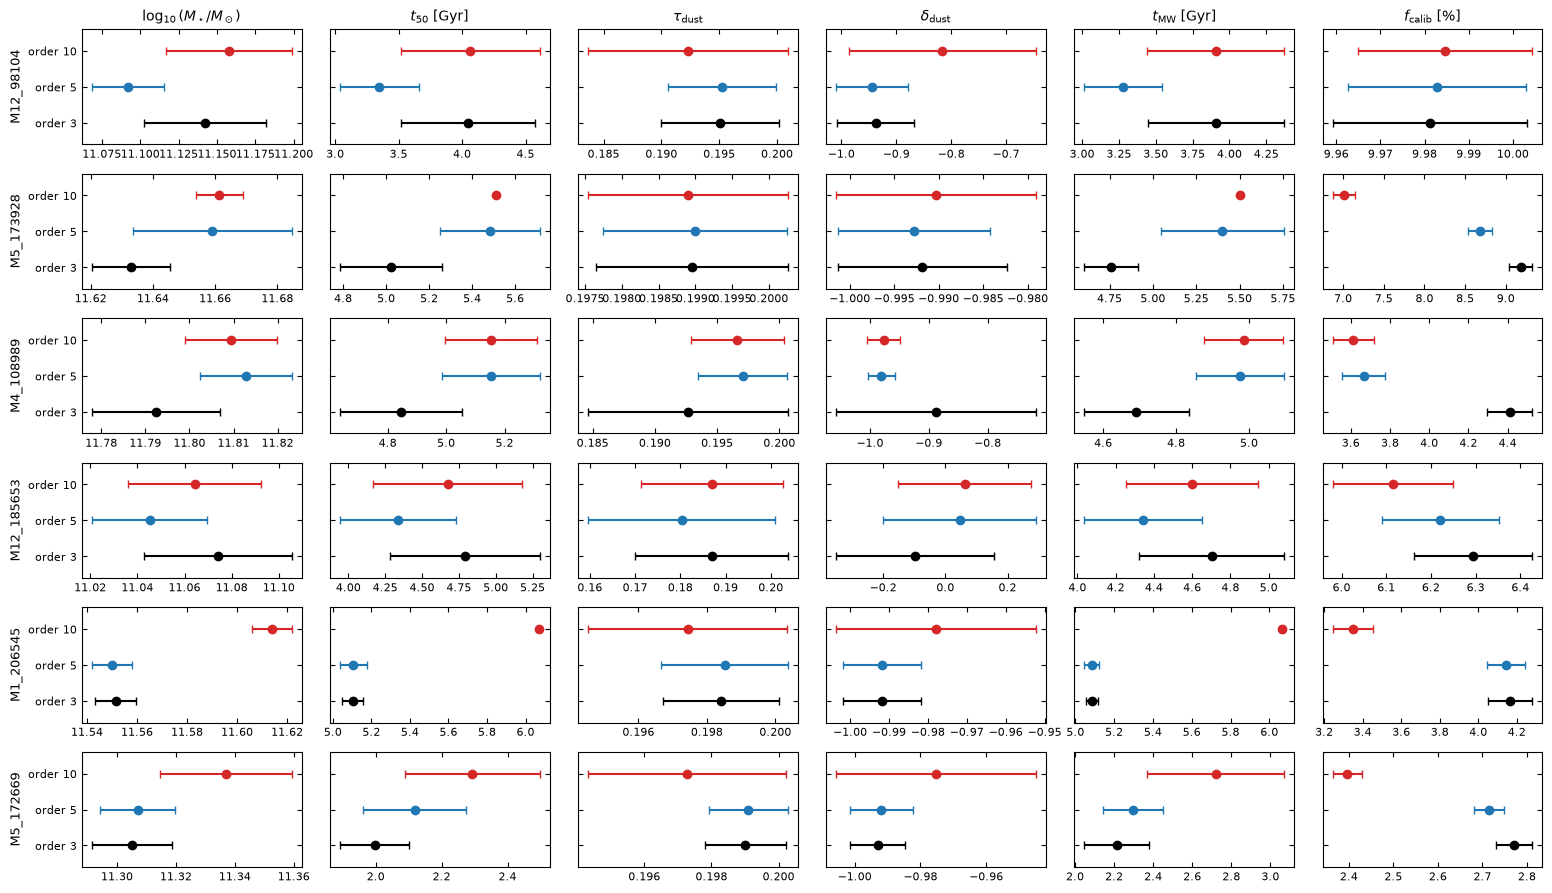

In [9]:
params = ["logmass", "t50", "tau_dust", "dust_index", "age", "f_calib"]
fig, axes = plt.subplots(len(galaxies), len(params), figsize=(2.6 * len(params), 1.5 * len(galaxies)), squeeze=False)
for r, target in enumerate(galaxies):
    for c, name in enumerate(params):
        ax = axes[r, c]
        for i, arm in enumerate(ARMS):
            if (target, arm) not in table.index:
                continue
            row = table.loc[(target, arm)]
            ax.errorbar(row[f"{name}_q50"], i, xerr=row[f"{name}_hw"], fmt="o", color=COLOURS[arm], capsize=3)
        ax.set_yticks(range(len(ARMS)))
        ax.set_yticklabels([f"order {table.loc[(target, a), 'order'] if (target, a) in table.index else ''}" for a in ARMS] if c == 0 else [""] * len(ARMS), fontsize=8)
        ax.set_ylim(-0.6, len(ARMS) - 0.4); ax.tick_params(axis="x", labelsize=8)
        if r == 0:
            ax.set_title(LABELS[name], fontsize=10)
        if c == 0:
            ax.set_ylabel(target, fontsize=9)
fig.tight_layout(); fig.savefig(RESULTS / "parameters-by-order.png", dpi=130); plt.show()

## Star-formation histories by order

- Left: normalised SFR median with 16-84 band. Right: cumulative mass fraction younger than lookback time.

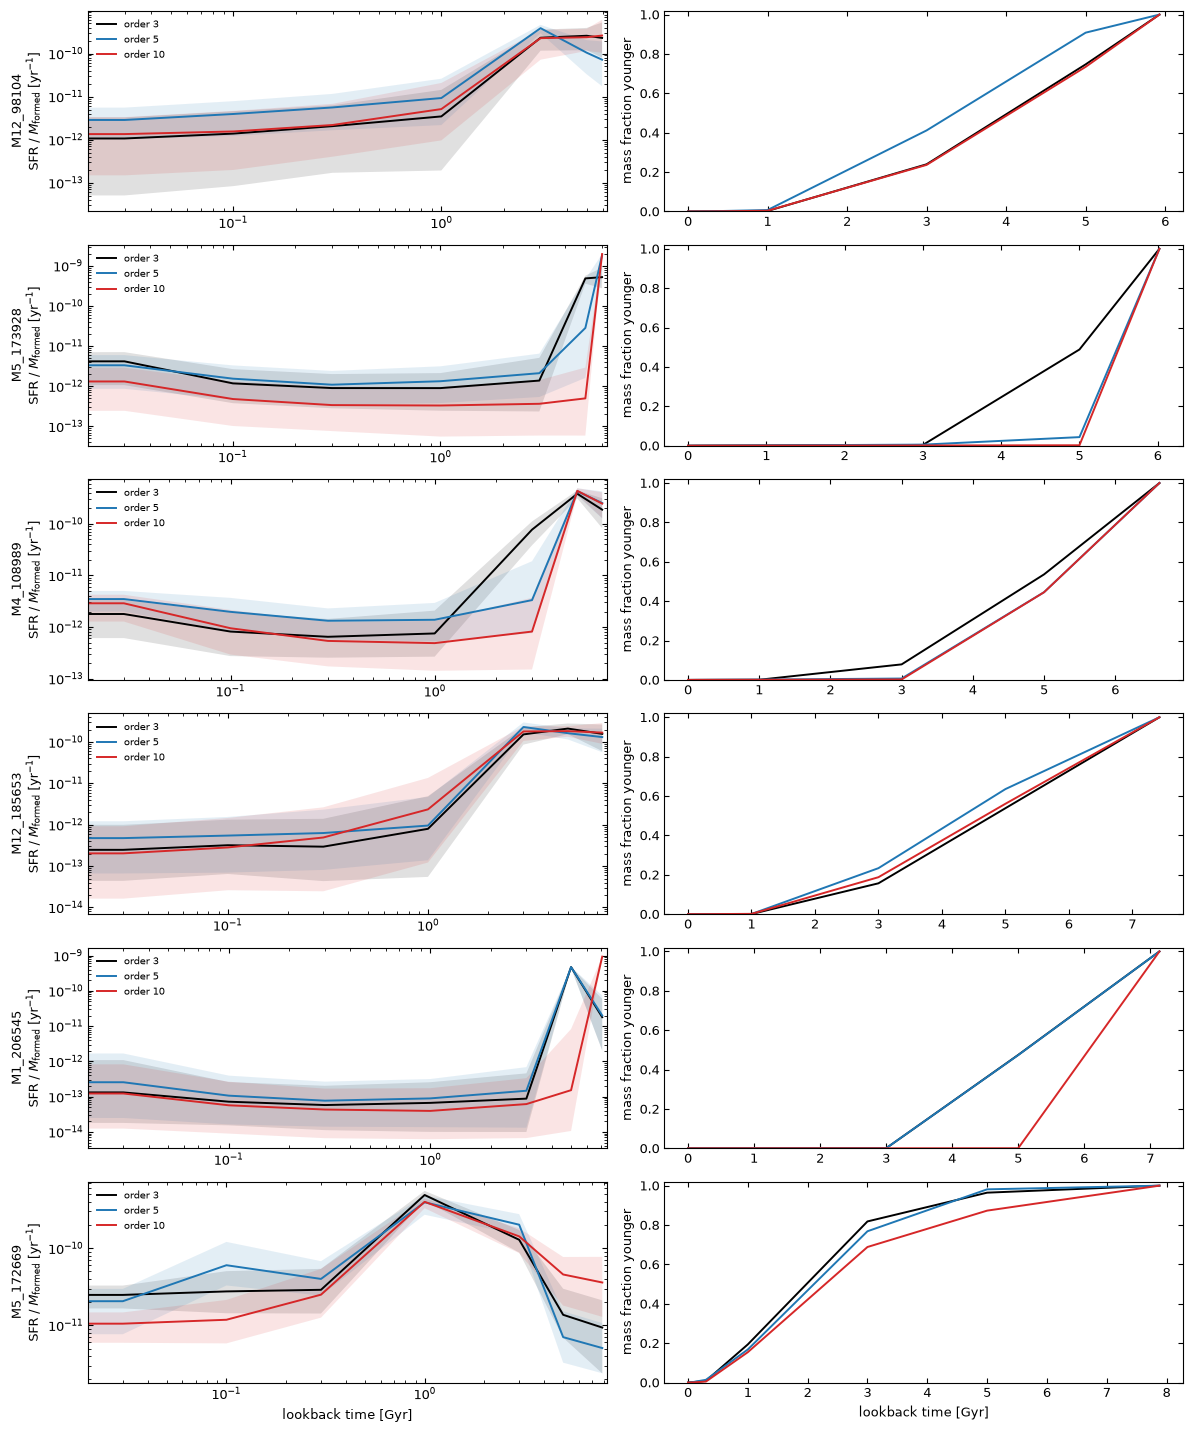

In [10]:
fig, axes = plt.subplots(len(galaxies), 2, figsize=(12, 2.4 * len(galaxies)), squeeze=False)
for r, target in enumerate(galaxies):
    for arm in arms_present:
        if (arm, target) not in fits:
            continue
        sfh = fits[(arm, target)]["sfh"]; lb = sfh["lookback_time_gyr"]; order = fits[(arm, target)]["calibration"]["attrs"]["order"]
        axes[r, 0].plot(lb, sfh["normalized_sfr_q50"], color=COLOURS[arm], lw=1.4, label=f"order {order}")
        axes[r, 0].fill_between(lb, sfh["normalized_sfr_q16"], sfh["normalized_sfr_q84"], color=COLOURS[arm], alpha=0.12, lw=0)
        younger = np.concatenate([[0.0], np.cumsum(sfh["mass_fraction_q50"])])
        axes[r, 1].plot(lb, younger / younger[-1], color=COLOURS[arm], lw=1.4, label=f"order {order}")
    axes[r, 0].set(xscale="log", yscale="log", ylabel=f"{target}\n" + r"SFR / $M_{\rm formed}$ [yr$^{-1}$]")
    axes[r, 0].set_xlim(0.02, lb[-1] * 1.05)
    axes[r, 1].set(ylabel="mass fraction younger", ylim=(0, 1.02))
    axes[r, 0].legend(frameon=False, fontsize=7)
for ax in axes[-1]:
    ax.set_xlabel("lookback time [Gyr]")
fig.tight_layout(); fig.savefig(RESULTS / "sfh-histories.png", dpi=130); plt.show()

## Posterior corners by order

- Weighted dead points; 1σ and 2σ contours; shared ranges across orders.

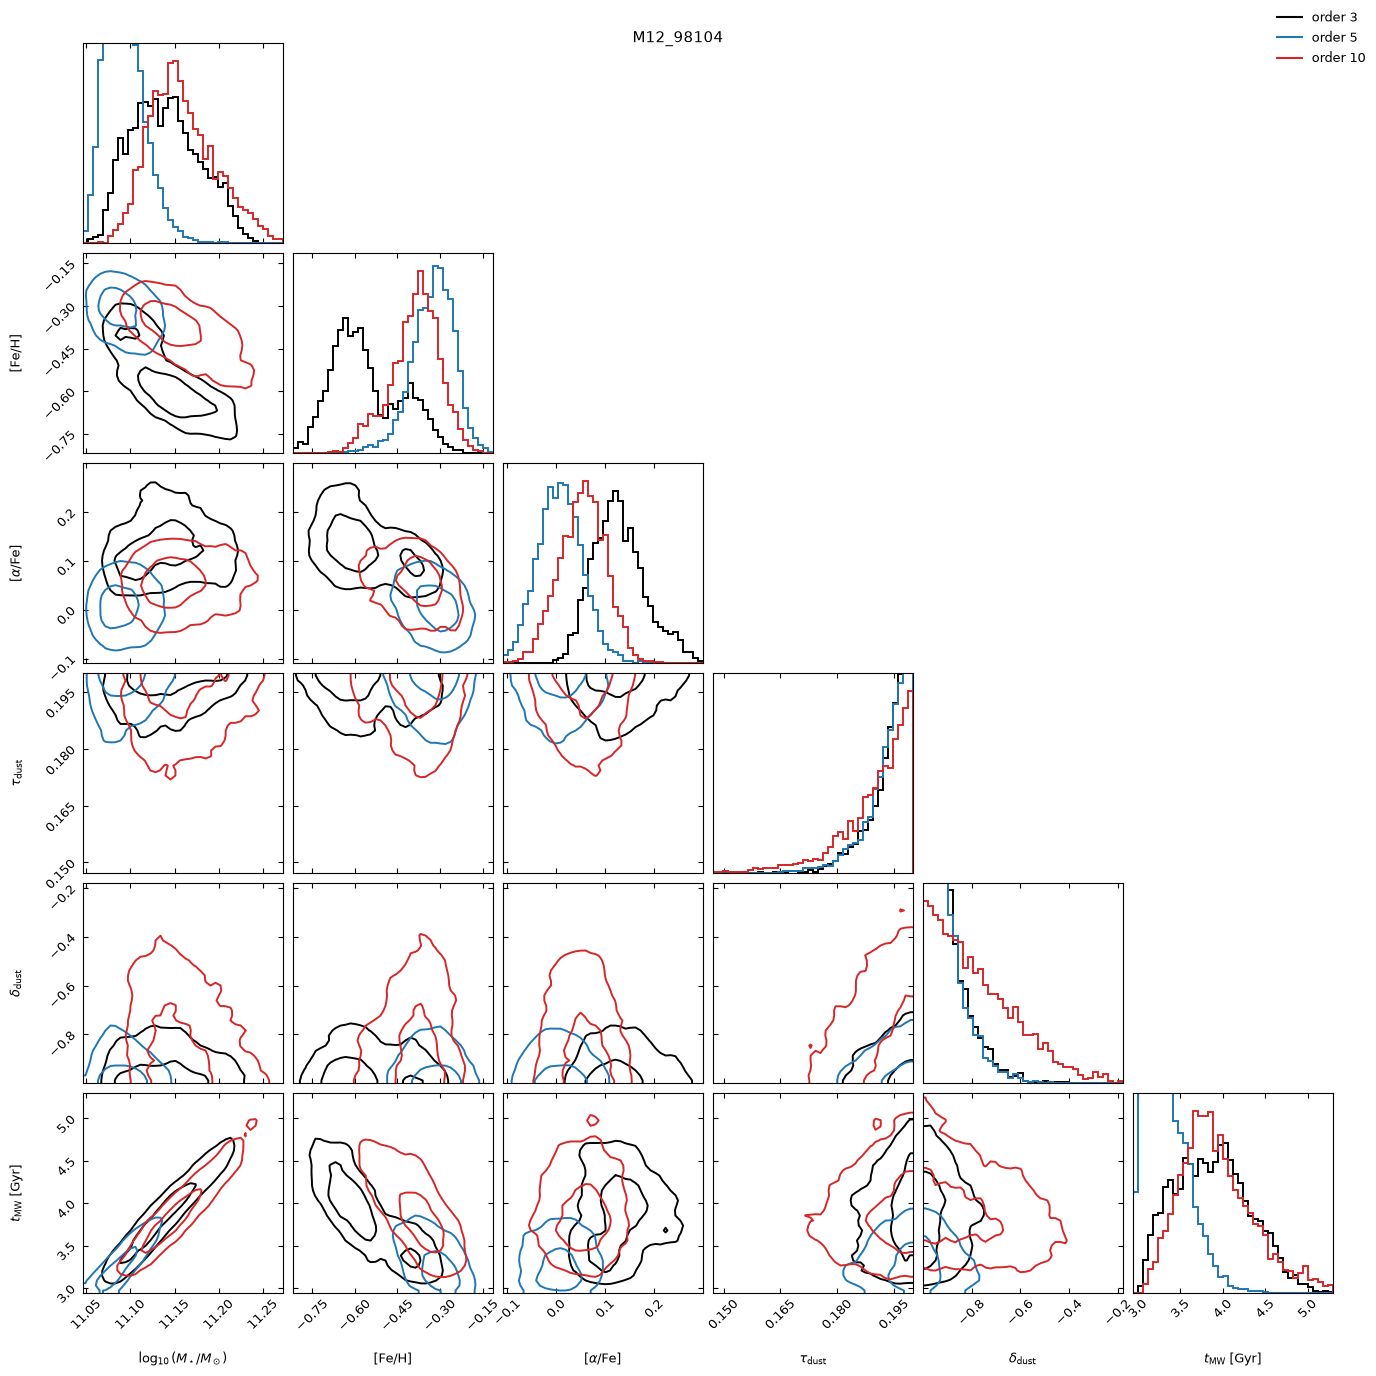

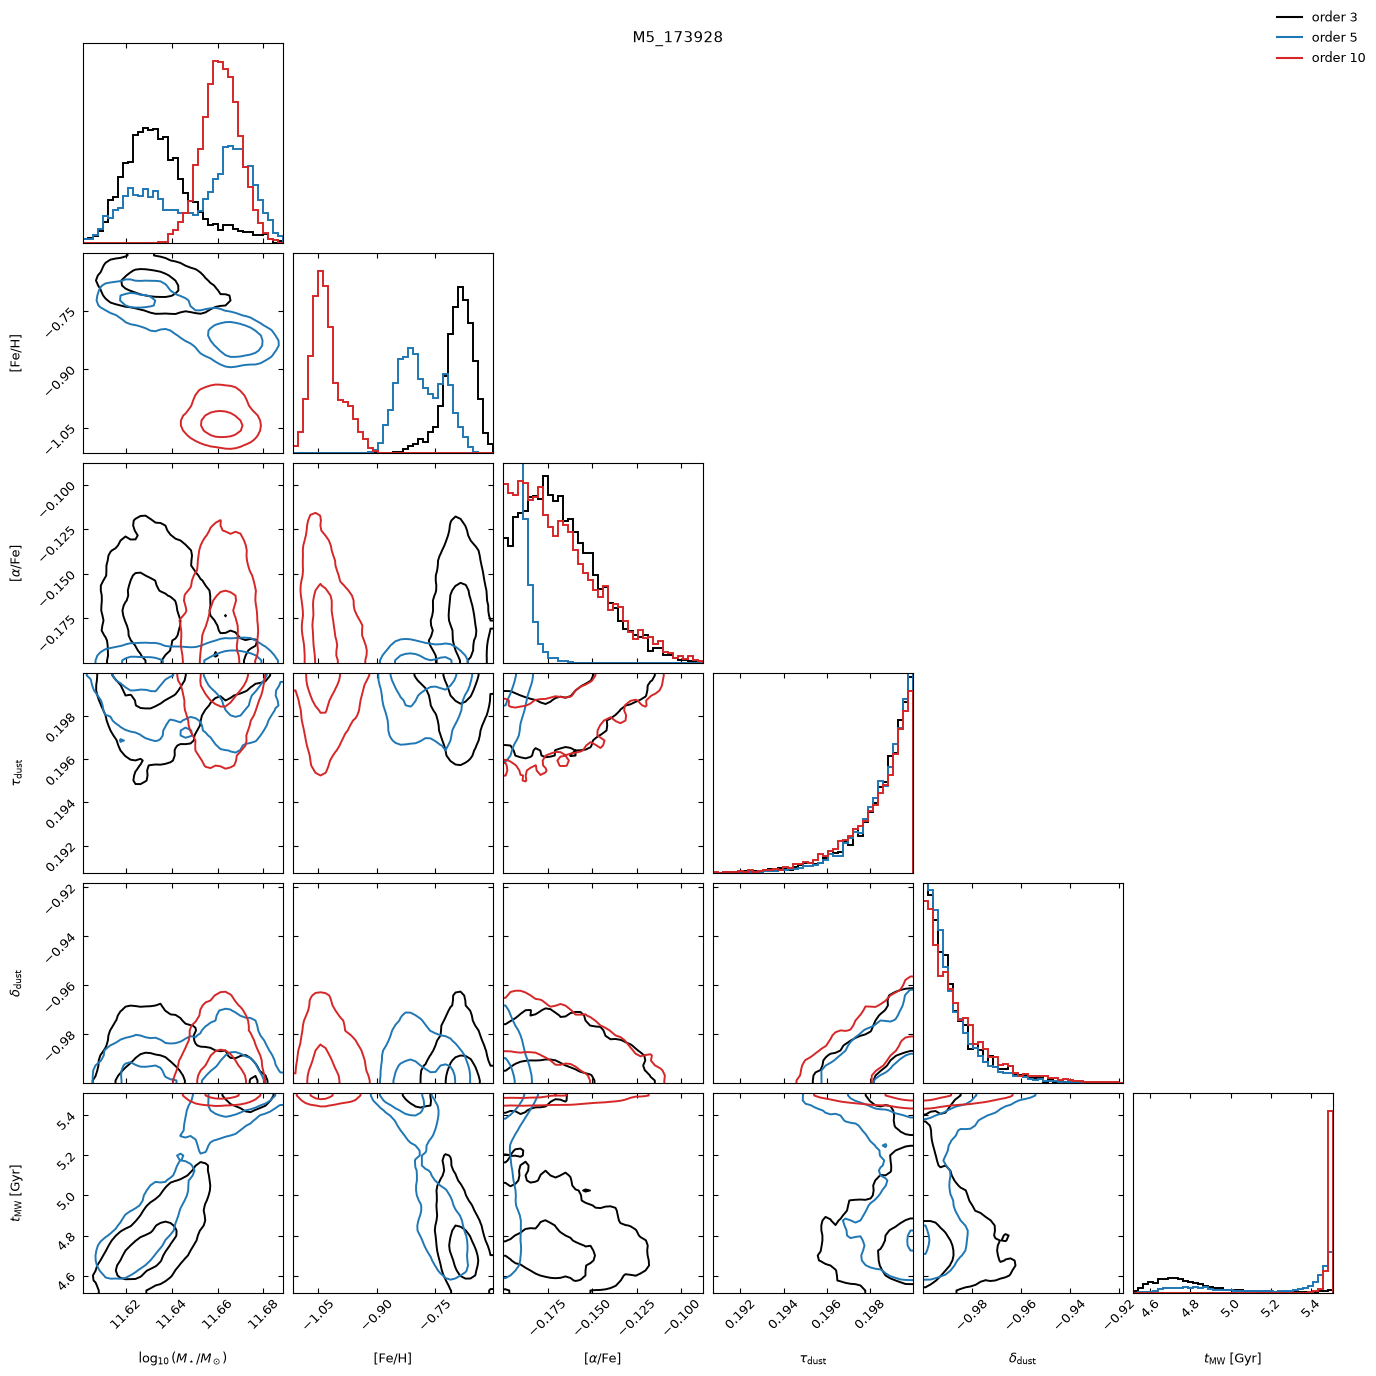

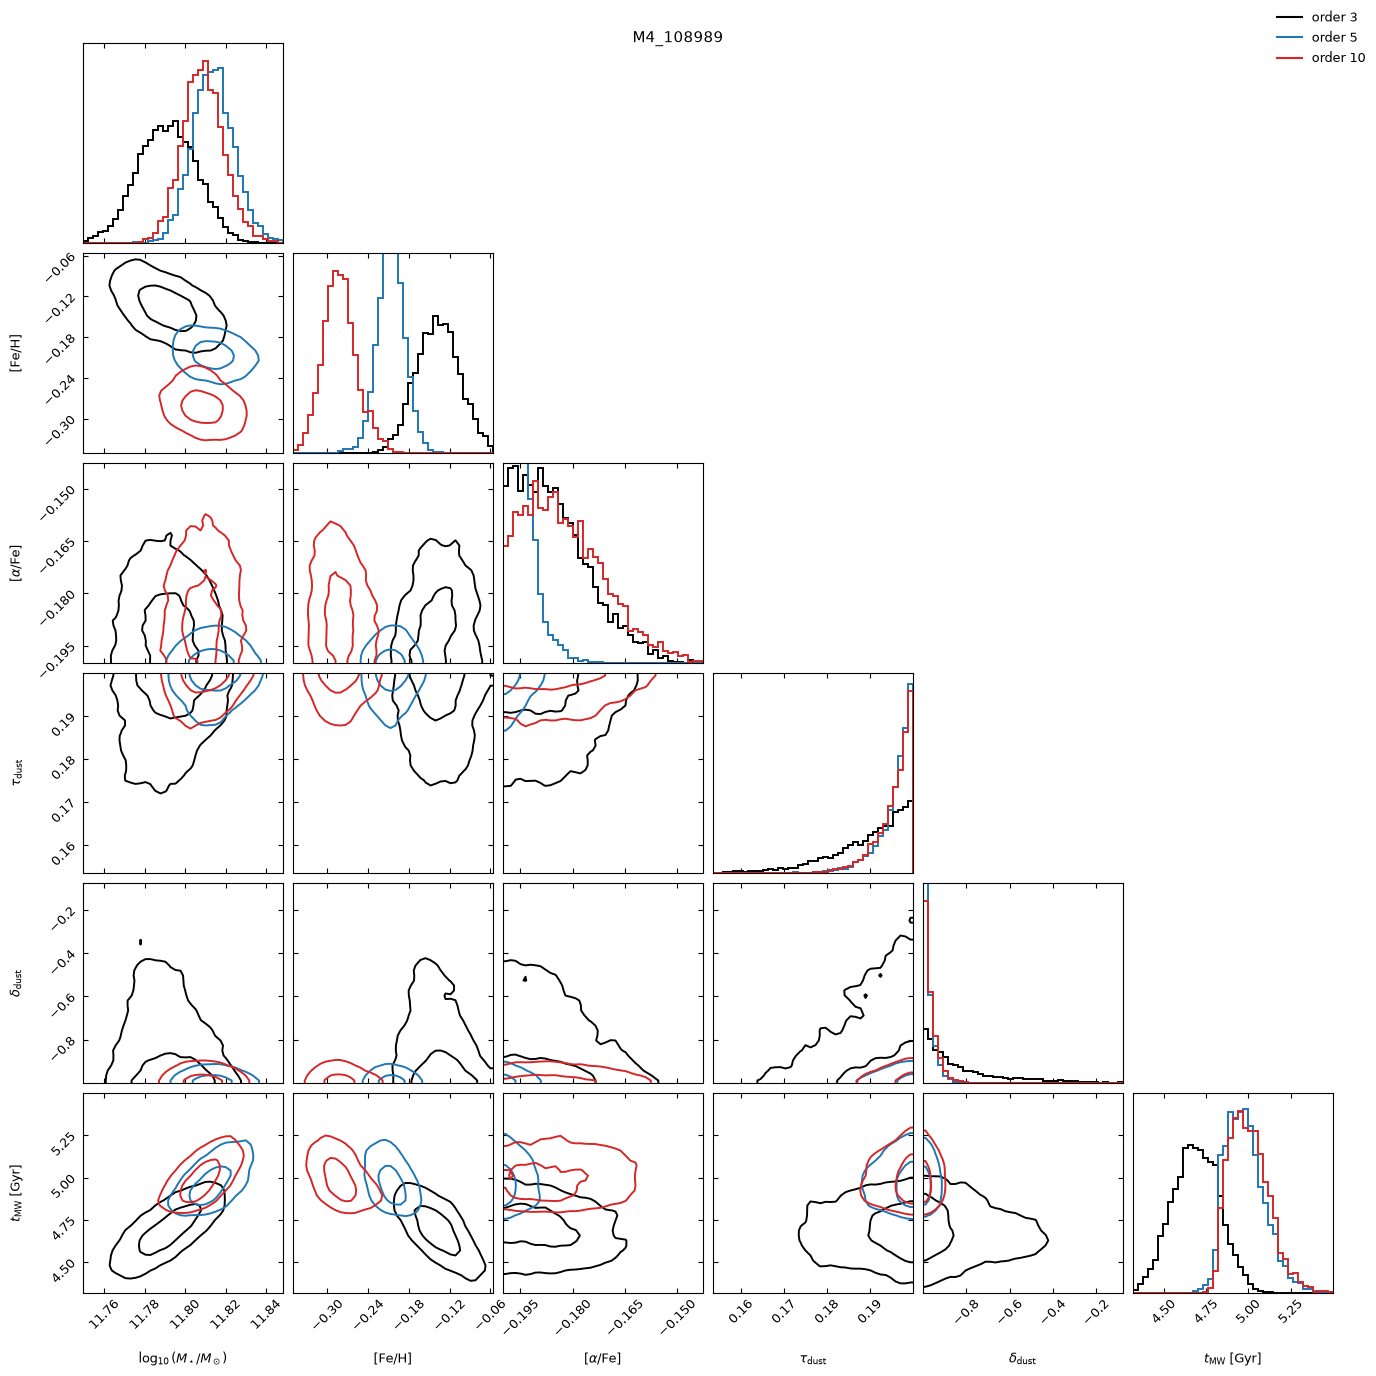

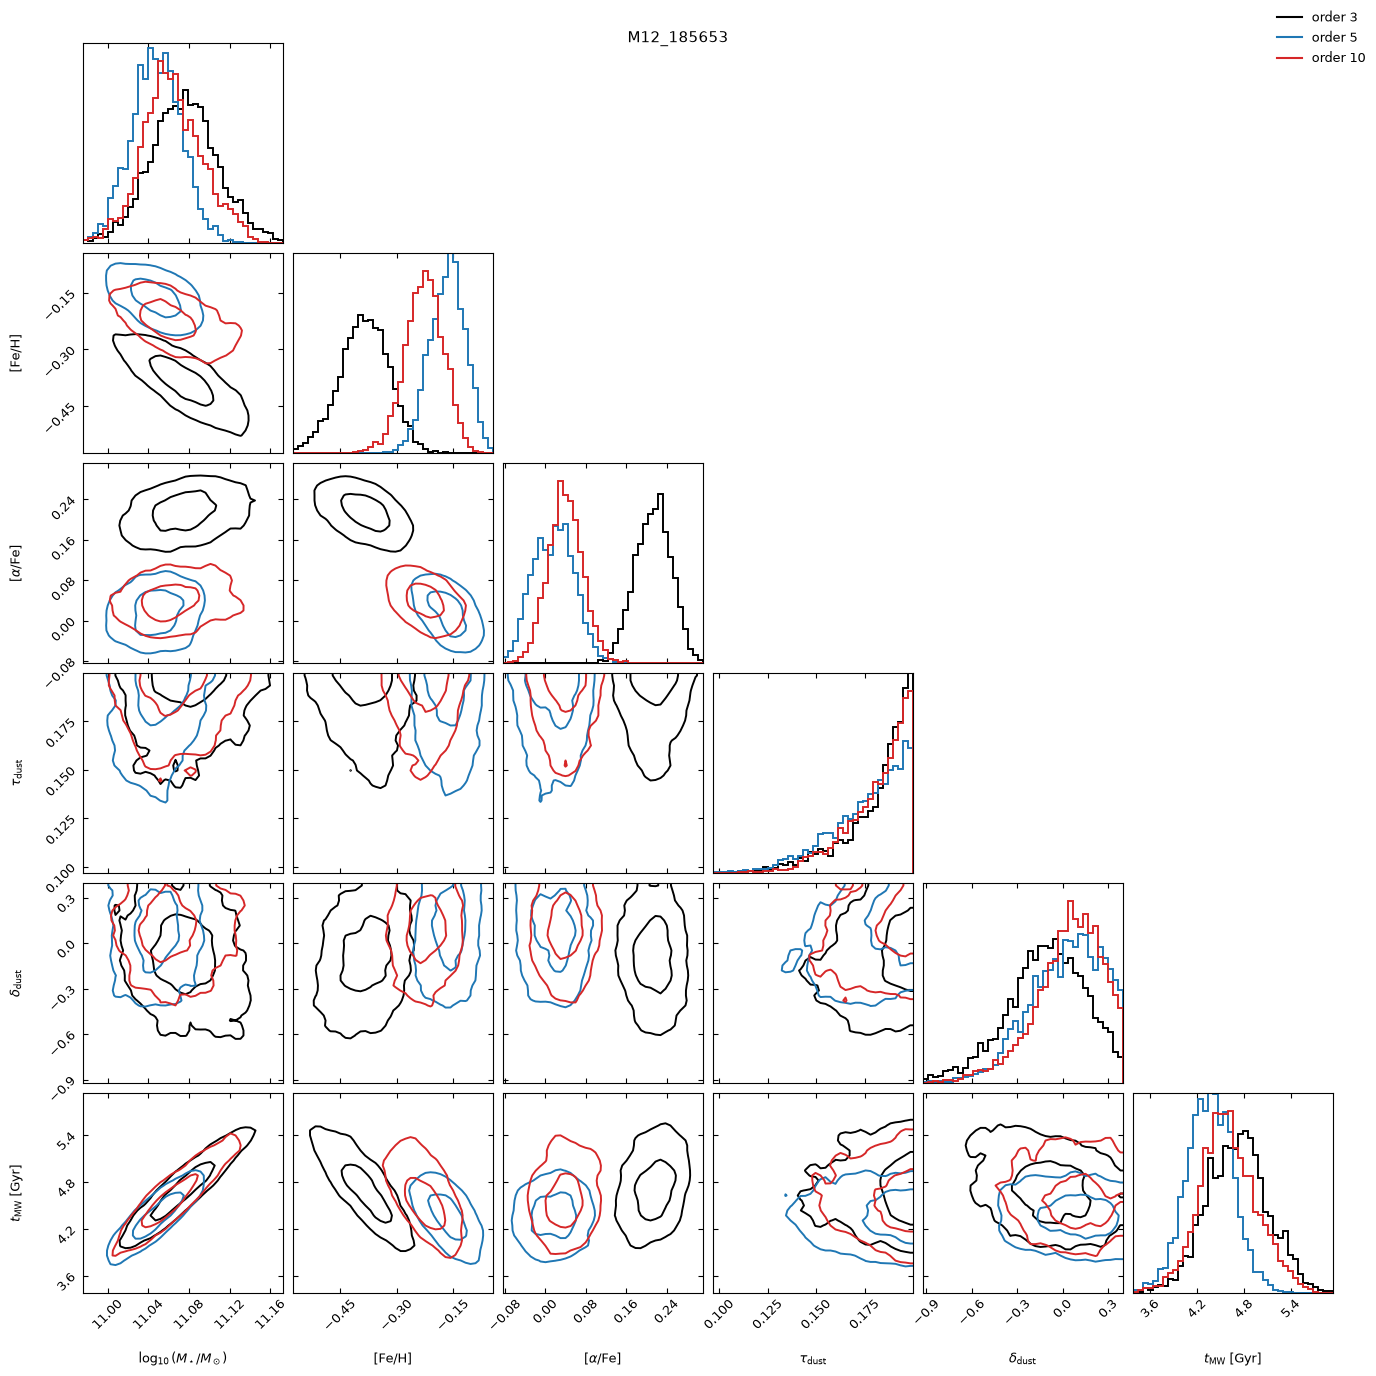

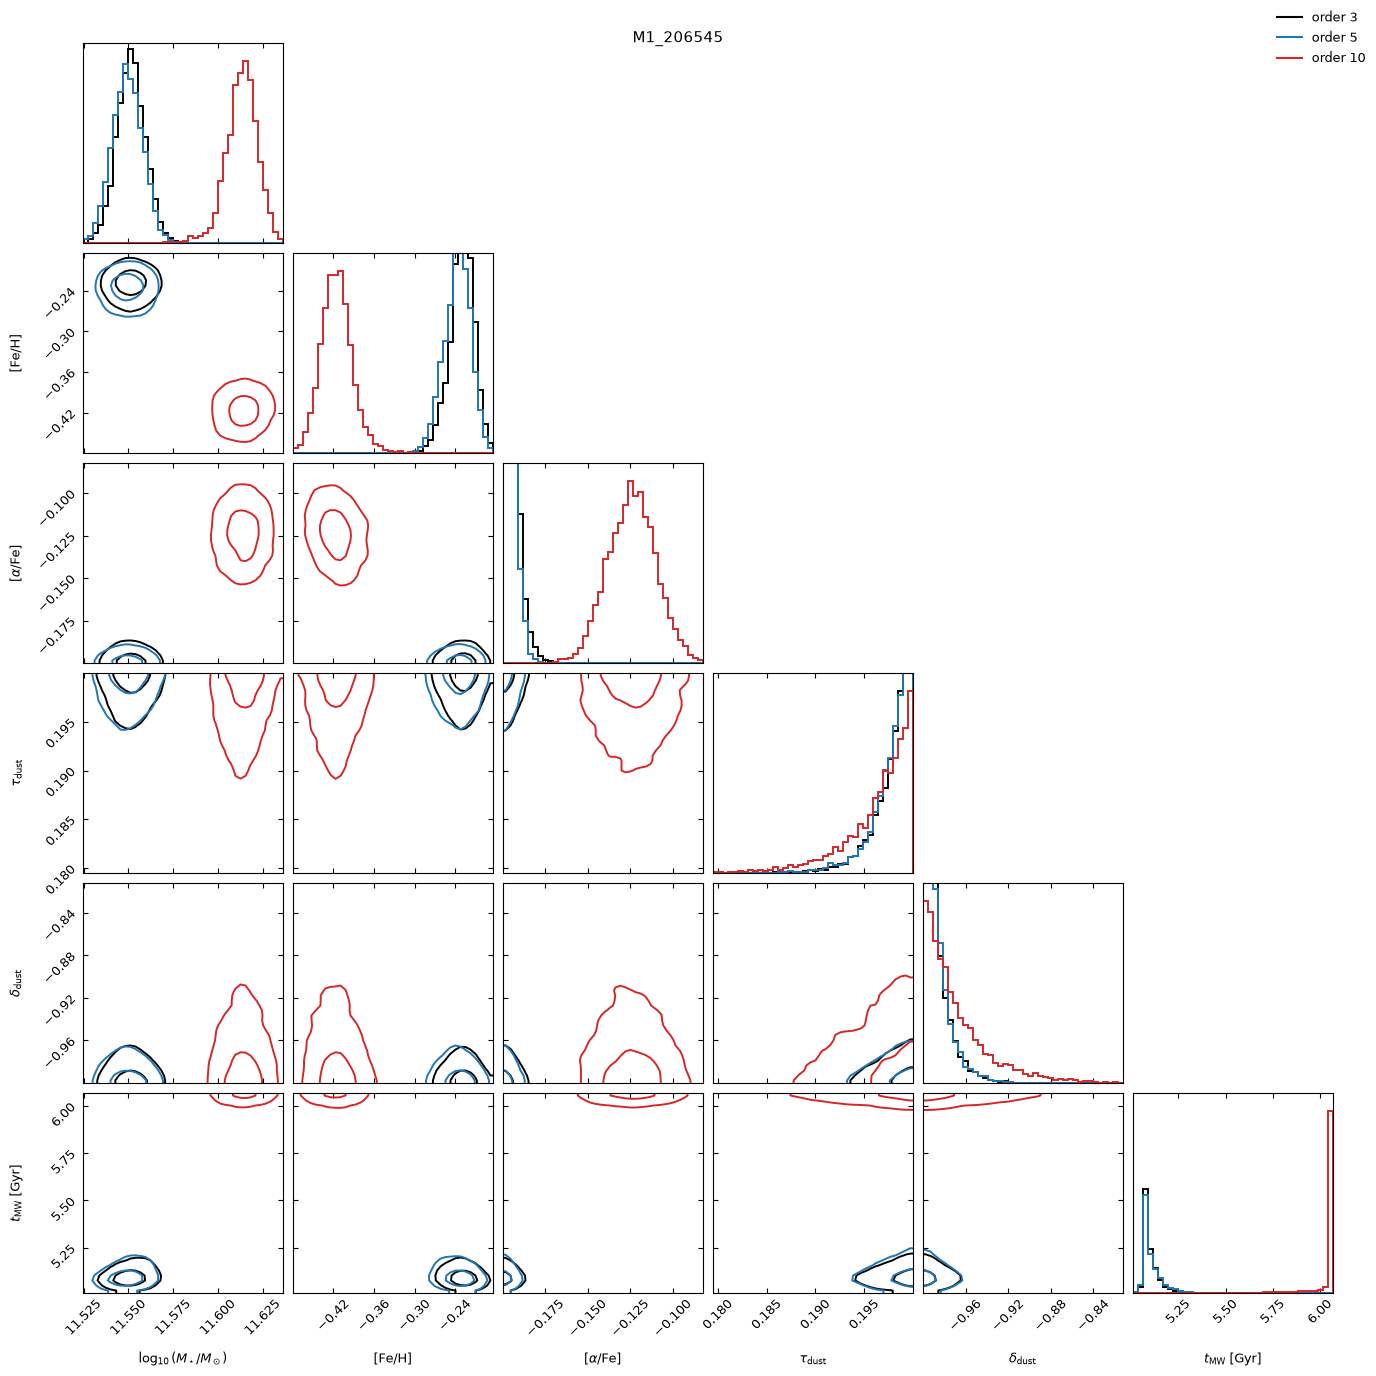

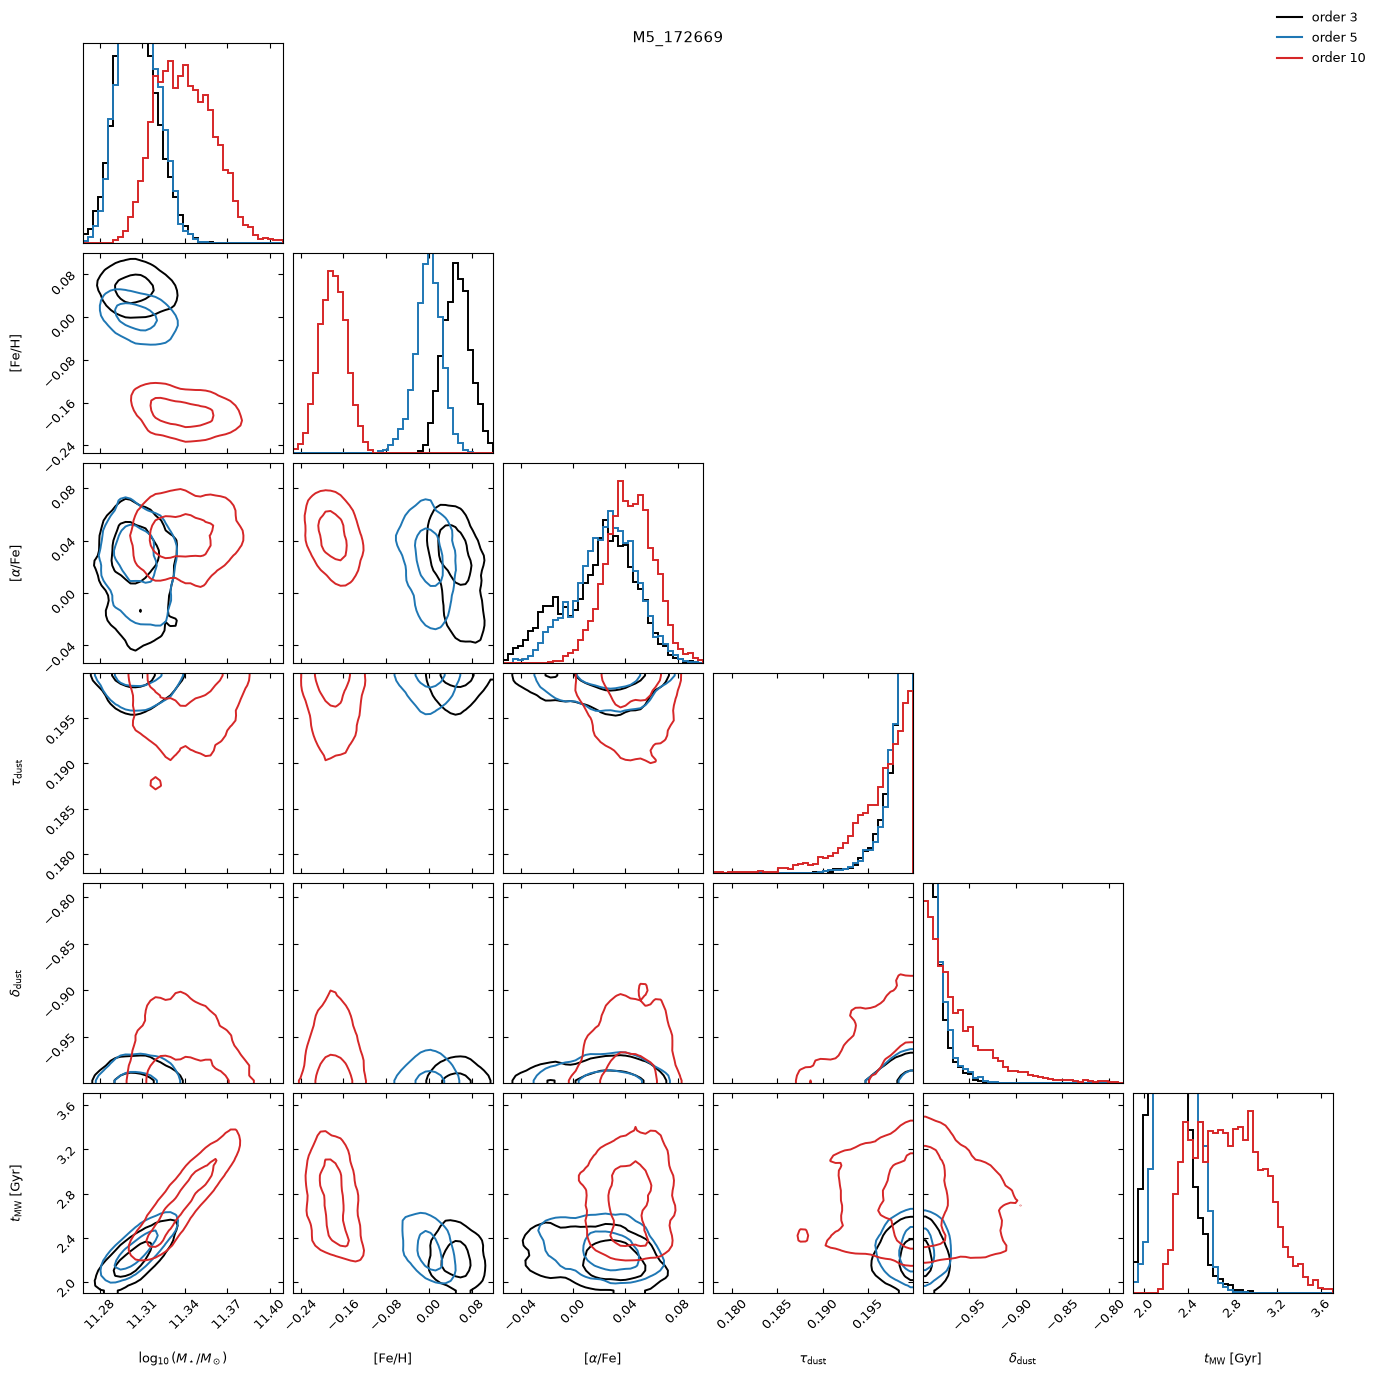

In [11]:
CORNER_PARAMS = ["logmass", "Z", "afe", "tau_dust", "dust_index", "age"]
CORNER_LABELS = [LABELS[p] for p in CORNER_PARAMS]


def mw_age_samples(g):
    r = np.asarray(g.samples["logsfr_ratios"])
    h = 10.0 ** np.concatenate([np.zeros((len(r), 1)), -np.cumsum(r, axis=1)], axis=1)
    edges = g.sfh_edges_gyr
    m = 0.5 * (h[:, :-1] + h[:, 1:]) * np.diff(edges)
    return (m * (0.5 * (edges[:-1] + edges[1:]))).sum(1) / m.sum(1)


def corner_data(g):
    return np.column_stack([g.samples["logmass"], g.samples["Z"] + FEH_OFFSET, g.samples["afe"], g.samples["diffuse_tau_kc"],
                            g.samples["diffuse_dust_index"], mw_age_samples(g)])


for target in galaxies:
    present = [a for a in arms_present if (a, target) in fits]
    data = {a: (corner_data(fits[(a, target)]["galaxy"]), pgd.posterior_weights(fits[(a, target)]["galaxy"])) for a in present}
    k = len(CORNER_PARAMS)
    lo = np.min([[pgd.weighted_quantile(x[:, i], w, 0.002) for i in range(k)] for x, w in data.values()], axis=0)
    hi = np.max([[pgd.weighted_quantile(x[:, i], w, 0.998) for i in range(k)] for x, w in data.values()], axis=0)
    rng_ = [(a, b) if b > a else (a - 1e-3, a + 1e-3) for a, b in zip(lo, hi)]
    fig = None
    for a in present:
        x, w = data[a]
        fig = corner.corner(x, weights=w, labels=CORNER_LABELS, range=rng_, color=COLOURS[a], fig=fig, bins=40, smooth=1.0,
                            plot_datapoints=False, plot_density=False, fill_contours=False, levels=[1 - np.exp(-0.5), 1 - np.exp(-2.0)],
                            hist_kwargs=dict(density=True, lw=1.4), contour_kwargs=dict(linewidths=1.4))
    fig.legend(handles=[plt.Line2D([], [], color=COLOURS[a], label=f"order {fits[(a, target)]['calibration']['attrs']['order']}") for a in present],
               loc="upper right", frameon=False, fontsize=9)
    fig.suptitle(target, y=0.98)
    fig.savefig(RESULTS / f"corner-{target}.png", dpi=110); plt.show()

## Wiki figures

- Copy the figures beside the wiki note.

In [12]:
WIKI_FIGURES.mkdir(parents=True, exist_ok=True)
for png in sorted(RESULTS.glob("*.png")):
    shutil.copy2(png, WIKI_FIGURES / png.name)
print(sorted(p.name for p in WIKI_FIGURES.glob("*.png")))

['chi2-M12_185653.png', 'chi2-M12_98104.png', 'chi2-M1_206545.png', 'chi2-M4_108989.png', 'chi2-M5_172669.png', 'chi2-M5_173928.png', 'coefficients.png', 'corner-M12_185653.png', 'corner-M12_98104.png', 'corner-M1_206545.png', 'corner-M4_108989.png', 'corner-M5_172669.png', 'corner-M5_173928.png', 'fit-M12_185653.png', 'fit-M12_98104.png', 'fit-M1_206545.png', 'fit-M4_108989.png', 'fit-M5_172669.png', 'fit-M5_173928.png', 'parameters-by-order.png', 'polynomial-vectors.png', 'sfh-histories.png']
